In [1]:
%%capture output
! pip install ibllib
! pip install pynapple
! pip install git+https://github.com/int-brain-lab/paper-brain-wide-map.git
! pip install -U google-colab

In [ ]:
# system
from pathlib import Path

# analysis
import numpy as np
import pandas as pd
import pynapple as nap
from scipy import stats
import glob 
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings
import os
from scipy.interpolate import interp1d

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
from sklearn.decomposition import PCA

# set the IBL style for figures
# from ibl_style.style import figure_style
# figure_style()
from reproducible_ephys_functions import get_insertions
from functions import idxs_from_files, define_trial_types
from one.api import ONE
one= ONE()

In [4]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'


# Load trial data

In [5]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# session_cluster = pd.read_parquet(data_path+'cluster_per_session')
trial_modes = pd.read_parquet(data_path+'18_trial_waterclust')
trial_modes = trial_modes[['session', 'sample', 'trial_cluster']].drop_duplicates()
trial_modes['index'] = trial_modes['sample'].str.split().str[1:2].str.join('').astype(float)
trial_modes = trial_modes.rename(columns={'index':'trial_id', 'session':'eid'})

In [6]:
insertions = get_insertions(level=0, one=one, freeze='freeze_2024_03')
repro_ephys_insertions = pd.DataFrame.from_dict(insertions)

In [7]:
repro_eid = repro_ephys_insertions['probe_insertion']

In [8]:
import brainwidemap
# this dataframe holds a summary of all the sessions
# and for us importantly, the eids and pids
bwm_df = brainwidemap.bwm_query()  # each row of this dataframe is a recording

n_sessions = bwm_df["eid"].unique().shape[0]
n_insertions = bwm_df["pid"].unique().shape[0]
print(
    f"{n_sessions} sessions with {n_insertions} individual neuropixel recordings"
)
# bwm_df.head()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
459 sessions with 699 individual neuropixel recordings


In [9]:
bwm_pid = bwm_df['pid'].unique()

## Getting units from the brainwide map

In [10]:
units_df = brainwidemap.bwm_units(one)
n_units = units_df.shape[0]
print(f"{n_units} units present in the table")
# units_df.head()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01
62990 units present in the table


In [11]:
# use_eid = lda_pid
use_eid = repro_eid
# use_eid = bwm_pid

In [12]:
repro_units = units_df.loc[units_df['pid'].isin(list(use_eid))]

In [13]:
# Here we repeat the imports and instantiate ONE, so this cell can also be run stand-alone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage

from iblutil.numerical import bincount2D
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from ibl_style.style import figure_style

figure_style()  # set the style for IBL figures

one_kwargs = dict(
    base_url='https://openalyx.internationalbrainlab.org',
    username='intbrainlab',
    password='international',
    silent=True,
)
one = ONE(**one_kwargs)

def psth_indices(times, t_events, fs=None, event_window=np.array([-1, 1])):
    """
    Compute the peri-event time indices
    :param signal:
    :param times:
    :param t_events:
    :param fs:
    :param event_window:
    :return: idx_psth: (nc, nt), tscale
    """
    event_window = np.array(event_window)
    if fs is None:
        fs = 1 / np.nanmedian(np.diff(times))
    # compute a vector of indices corresponding to the perievent window at the given sampling rate
    sample_window = np.round(
        np.arange(event_window[0] * fs, event_window[1] * fs + 1)
    ).astype(int)
    # we inflate this vector to a 2d array where each column corresponds to an event
    idx_psth = np.tile(sample_window[:, np.newaxis], (1, t_events.size))
    # we add the index of each event too their respective column
    idx_event = np.searchsorted(times, t_events)
    idx_psth += idx_event
    # here we handle the case where the event window is outside of the initial boundaries
    i_out_of_bounds = np.logical_or(idx_psth > (times.size - 1), idx_psth < 0)
    idx_psth[i_out_of_bounds] = -1
    return idx_psth, sample_window.astype(float) / fs


def compute_binned_psths(st, sc, t_events, dt=0.02, event_window=np.array([-1, 1])):
    raster, t_scale, c_scale = bincount2D(st, sc, xbin=dt)
    ipsth, tscale = psth_indices(t_scale, t_events=t_events, event_window=event_window)
    return raster[:, ipsth], tscale  # (nc, nt, ne)

def extract_perievent(raster, t_scale, t_events, event_window):
    ipsth, tscale = psth_indices(
        t_scale, t_events=t_events, event_window=event_window
    )
    return raster[:, ipsth], tscale  # (nc, nt, ne)

def compute_binned_psths_with_baseline(
    st,
    sc,
    t_events,
    t_baseline_events,
    dt=0.02,
    event_window=np.array([-1, 1]),
    baseline_window=np.array([-0.5, 0])
):
    # bin spikes
    raster, t_scale, c_scale = bincount2D(st, sc, xbin=dt)

    # PSTH aligned to main event
    psth, tscale = extract_perievent(
        raster, t_scale, t_events, event_window)  # (nc, nt, ne)

    # baseline aligned to different event
    baseline, _ = extract_perievent(
        raster, t_scale, t_baseline_events, baseline_window)  # (nc, ntb, ne_b)

    # mean baseline per neuron
    # baseline_mean = np.nanmean(baseline, axis=(1, 2), keepdims=True)
    baseline_mean = np.nanmean(baseline, axis=1, keepdims=True)
    # shape: (nc, 1, 1)

    psth_bs = psth - baseline_mean

    return psth_bs, tscale, baseline_mean

## Querying and loading the data

Then we will query the brain region ACA. ACA has many sub-regions, and we need to get the list of neurons belinging to any of the sub-regions.

In [14]:
BRAIN_REGIONS = ['PPC', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions

regions = BrainRegions()
aca_leaf_nodes = regions.descendants(regions.acronym2id(BRAIN_REGIONS))
# print(f"List of regions to query: \n {aca_leaf_nodes['acronym']}")
BRAIN_REGIONS = repro_units['Beryl'].unique()  # All available in the session query

# Process and save PETH with trial info

In [15]:
# LOAD DATA
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'

all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/states_files/'

# Individual sessions

In [16]:
# Identify sessions available to process
sessions_to_process = []
for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]
    sessions_to_process.append((mouse_name, session))
print(f"Found {len(sessions_to_process)} sessions to process.")

Found 319 sessions to process.


In [17]:
def timewarp_spike_counts(spike_counts, target_length, smooth, sigma, return_intermediates=False):
    """
    Timewarp spike count data using smooth interpolation.
    
    Args:
        spike_counts: array of spike counts over time
        target_length: desired length after timewarping
        smooth: whether to apply Gaussian smoothing before interpolation
        sigma: standard deviation for Gaussian smoothing kernel
        return_intermediates: if True, return intermediate steps for visualization
    
    Returns:
        interpolated spike counts of target_length, optionally with intermediates
    """
    if len(spike_counts) == 0:
        result = np.full(target_length, np.nan)
        if return_intermediates:
            return result, None, None, None
        return result
    
    # Remove NaN values
    spike_counts = np.array(spike_counts)
    valid_mask = ~np.isnan(spike_counts)
    
    if not np.any(valid_mask):
        result = np.full(target_length, np.nan)
        if return_intermediates:
            return result, None, None, None
        return result
    
    valid_counts = spike_counts[valid_mask]
    valid_indices = np.where(valid_mask)[0]
    
    if len(valid_counts) == 1:
        result = np.full(target_length, valid_counts[0])
        if return_intermediates:
            return result, valid_counts, valid_indices, None
        return result
    
    # Store original valid counts for plotting
    original_valid_counts = valid_counts.copy()
    
    # Apply smoothing if requested
    smoothed_counts = None
    if smooth and len(valid_counts) > 3:
        from scipy.ndimage import gaussian_filter1d
        smoothed_counts = gaussian_filter1d(valid_counts, sigma=sigma)
        valid_counts = smoothed_counts
    
    # Use cubic spline interpolation for smoother results
    normalized_valid_x = valid_indices / (len(spike_counts) - 1) if len(spike_counts) > 1 else [0]
    target_x = np.linspace(0, 1, target_length)
    
    # Use cubic spline (or quadratic if not enough points)
    if len(valid_counts) >= 4:
        kind = 'cubic'
    elif len(valid_counts) >= 3:
        kind = 'quadratic'
    else:
        kind = 'linear'
    
    interp_func = interp1d(normalized_valid_x, valid_counts, kind=kind, 
                          fill_value='extrapolate', bounds_error=False)
    
    result = interp_func(target_x)
    
    if return_intermediates:
        return result, original_valid_counts, valid_indices, smoothed_counts
    return result

def plot_timewarping_comparison(df_grouped, example_indices, area, target_length):
    """
    Plot original vs timewarped spike count data with intermediate steps.
    """
    fig, axes = plt.subplots(len(example_indices), 4, figsize=(16, 3*len(example_indices)))
    if len(example_indices) == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(example_indices):
        row = df_grouped.iloc[idx]
        original_spikes = np.array(row[f'{area}_spike_count'])
        
        # Get intermediate steps
        timewarped_spikes, original_valid, valid_indices, smoothed = timewarp_spike_counts(
            original_spikes, target_length, smooth=True, sigma=1.0, return_intermediates=True
        )
        
        # Original data
        axes[i, 0].plot(original_spikes, 'b-', linewidth=2, label='Original')
        if original_valid is not None and valid_indices is not None:
            axes[i, 0].scatter(valid_indices, original_valid, color='blue', s=30, alpha=0.7, label='Valid points')
        axes[i, 0].set_title(f'Original: {row["trial_epoch"]}\n(Sample {row["trial_id"]}) Length: {len(original_spikes)}')
        axes[i, 0].set_ylabel('Spike Count')
        axes[i, 0].set_xlabel('Time Bin')
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend()
        
        # Smoothed data (if smoothing was applied)
        if smoothed is not None and valid_indices is not None:
            axes[i, 1].plot(valid_indices, original_valid, 'b-', linewidth=1, alpha=0.5, label='Original valid')
            axes[i, 1].plot(valid_indices, smoothed, 'g-', linewidth=2, label='Smoothed')
            axes[i, 1].scatter(valid_indices, smoothed, color='green', s=30, alpha=0.7)
            axes[i, 1].set_title(f'Smoothed Data\n(σ={1.0})')
        else:
            # If no smoothing, show the valid points again
            if original_valid is not None and valid_indices is not None:
                axes[i, 1].plot(valid_indices, original_valid, 'b-', linewidth=2, label='No smoothing applied')
                axes[i, 1].scatter(valid_indices, original_valid, color='blue', s=30, alpha=0.7)
            axes[i, 1].set_title('No Smoothing Applied')
        axes[i, 1].set_ylabel('Spike Count')
        axes[i, 1].set_xlabel('Time Bin')
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()
        
        # Interpolation visualization
        if original_valid is not None and valid_indices is not None:
            # Show interpolation function over full range
            full_x = np.linspace(0, len(original_spikes)-1, 100)
            normalized_valid_x = valid_indices / (len(original_spikes) - 1) if len(original_spikes) > 1 else [0]
            full_normalized_x = full_x / (len(original_spikes) - 1) if len(original_spikes) > 1 else [0]
            
            # Use the smoothed data if available, otherwise original valid data
            interp_data = smoothed if smoothed is not None else original_valid
            
            # Determine interpolation kind
            if len(interp_data) >= 4:
                kind = 'cubic'
            elif len(interp_data) >= 3:
                kind = 'quadratic'
            else:
                kind = 'linear'
            
            interp_func = interp1d(normalized_valid_x, interp_data, kind=kind, 
                                  fill_value='extrapolate', bounds_error=False)
            full_interp = interp_func(full_normalized_x)
            
            axes[i, 2].plot(full_x, full_interp, 'purple', linewidth=2, alpha=0.7, label=f'{kind.title()} interpolation')
            axes[i, 2].scatter(valid_indices, interp_data, color='red', s=40, zorder=5, label='Control points')
        axes[i, 2].set_title(f'Interpolation Function\n({kind.title()} spline)')
        axes[i, 2].set_ylabel('Spike Count')
        axes[i, 2].set_xlabel('Time Bin')
        axes[i, 2].grid(True, alpha=0.3)
        axes[i, 2].legend()
        
        # Final timewarped data
        axes[i, 3].plot(timewarped_spikes, 'r-', linewidth=2, label='Timewarped')
        axes[i, 3].scatter(range(len(timewarped_spikes)), timewarped_spikes, color='red', s=20, alpha=0.7)
        axes[i, 3].set_title(f'Final Timewarped\nLength: {len(timewarped_spikes)}')
        axes[i, 3].set_ylabel('Spike Count')
        axes[i, 3].set_xlabel('Normalized Time Bin')
        axes[i, 3].grid(True, alpha=0.3)
        axes[i, 3].legend()
    
    plt.tight_layout()
    plt.show()


In [ ]:
def process_timewarped_spikes_all_areas(states_trial_with_spikes, areas, target_length=10, 
                                      trial_type_agg=['correct_str', 'contrast_str', 'block_str', 'choice'], 
                                      plot=False):
    """
    Process timewarped spikes for multiple brain areas.
    
    Parameters:
    -----------
    states_trial_with_spikes : pd.DataFrame
        Input dataframe with trial and spike data
    areas : list
        List of brain area names to process
    target_length : int, default=10
        Target length for timewarping
    trial_type_agg : list
        List of trial type aggregation columns
    plot : bool, default=False
        Whether to generate plots
    
    Returns:
    --------
    pd.DataFrame
        Dataframe with timewarped spikes for each area in separate columns
    """
    
    # Remove data without trials
    states_trial_clean = states_trial_with_spikes.dropna(subset=['goCueTrigger_times'])
    states_df = define_trial_types(states_trial_clean, trial_type_agg)
    
    # Initialize result dataframe
    all_sequences = pd.DataFrame()
    
    # Process each area
    for area in areas:
        print(f"Processing area: {area}")
        
        # Group by trial identifiers
        vars = ['trial_id', 'trial_type', 'trial_epoch', 'mouse_name']
        df_grouped = states_df.groupby(vars)[f'{area}_spike_count'].apply(list).reset_index()
        
        # Apply timewarping to spike counts
        df_grouped[f'{area}_timewarped_spikes'] = df_grouped[f'{area}_spike_count'].apply(
            lambda spikes: timewarp_spike_counts(spikes, target_length, smooth=True, sigma=2.0, return_intermediates=False)
        )
        
        # Plotting examples if requested
        if plot:
            # Get some example trials from different broader_labels
            unique_labels = df_grouped['trial_epoch'].unique()
            example_indices = []
            
            for label in unique_labels[:3]:  # Show first 3 label types
                label_indices = df_grouped[df_grouped['trial_epoch'] == label].index[:2]  # 2 examples per label
                example_indices.extend(label_indices)
            
            if example_indices:
                plot_timewarping_comparison(df_grouped, example_indices[:6], area, target_length)
        
        # Prepare area-specific data
        area_data = df_grouped[['mouse_name', 'trial_type', 'trial_id', 'trial_epoch', f'{area}_timewarped_spikes']]
        
        # Merge with results
        if all_sequences.empty:
            all_sequences = area_data
        else:
            all_sequences = all_sequences.merge(
                area_data, 
                on=['mouse_name', 'trial_type', 'trial_id', 'trial_epoch'], 
                how='outer'
            )
        
        print(f"Processed {len(df_grouped)} samples for {area}")
        print(f"Unique broader labels: {df_grouped['trial_epoch'].unique()}")
    
    return all_sequences

In [42]:
def process_timewarped_pcs_all_areas(states_trial_with_spikes, areas, target_length=10, 
                                      trial_type_agg=['correct_str', 'contrast_str', 'block_str', 'choice'], 
                                      plot=False, n_components=5):
    """
    Process timewarped spikes for multiple brain areas using PCA components.
    
    Parameters:
    -----------
    states_trial_with_spikes : pd.DataFrame
        Input dataframe with trial and spike data
    areas : list
        List of brain area names to process
    target_length : int, default=10
        Target length for timewarping
    trial_type_agg : list
        List of trial type aggregation columns
    plot : bool, default=False
        Whether to generate plots
    n_components : int, default=5
        Number of PCA components to process
    
    Returns:
    --------
    pd.DataFrame
        Dataframe with timewarped spikes for each area component in separate columns
    """
    
    # Remove data without trials
    states_trial_clean = states_trial_with_spikes.dropna(subset=['goCueTrigger_times'])
    states_df = define_trial_types(states_trial_clean, trial_type_agg)
    
    # Initialize result dataframe
    all_sequences = pd.DataFrame()
    
    # Process each area
    for area in areas:
        print(f"Processing area: {area}")
        
        # Group by trial identifiers
        vars = ['trial_id', 'trial_type', 'trial_epoch', 'mouse_name']
        
        # Process each PCA component for this area
        for comp_idx in range(1, n_components + 1):
            pc_col = f'{area}_pc{comp_idx}'
            if pc_col in states_df.columns:
                df_grouped = states_df.groupby(vars)[pc_col].apply(list).reset_index()
                
                # Apply timewarping to PCA component
                df_grouped[f'{area}_pc{comp_idx}_timewarped'] = df_grouped[pc_col].apply(
                    lambda spikes: timewarp_spike_counts(spikes, target_length, smooth=True, sigma=2.0, return_intermediates=False)
                )
                
                # Prepare area-component specific data
                area_data = df_grouped[['mouse_name', 'trial_type', 'trial_id', 'trial_epoch', f'{area}_pc{comp_idx}_timewarped']]
                
                # Merge with results
                if all_sequences.empty:
                    all_sequences = area_data
                else:
                    all_sequences = all_sequences.merge(
                        area_data, 
                        on=['mouse_name', 'trial_type', 'trial_id', 'trial_epoch'], 
                        how='outer'
                    )
        
        print(f"Processed PCA components for {area}")
    
    return all_sequences

## Decode

In [211]:
# --Machine learning and statistics
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder

shufflings = 1  #shuffling
model = RandomForestClassifier(random_state=42)
model = MultinomialNB()
repeats = 5
var = 'type'

In [21]:
def run_decoder(use_mat, model, shufflings, repeats, var):
    """
    RUN MODEL
    """

    # Generate random states for each iteration with a fixed seed
    # Loop over iterations of random draws of mice
    # Create empty dataframes to save results
    decoding_result = pd.DataFrame(columns=['shuffle', 'repeat', 'f1', 'confusion_matrix'])
    dec_result = pd.DataFrame(columns=['shuffle', 'repeat', 'f1', 'confusion_matrix'])

    # use_mat, named_labels = prepare_mat(df, final_matrix)

    for r in range(repeats):
        # print('Repeat %d of %d' % (r+1, repeats))  
        # Decoding function with 10-fold cross validation
        kf = KFold(n_splits=5, shuffle=True, random_state=0)
        # use_mat = mat.copy() # test using all mice

        # Find minimum number of samples per label
        labels = np.array(use_mat[var])
        labels_nr = np.arange(len(use_mat[var]))
        min_freq = np.min(use_mat[var].value_counts())
        # min_freq = 400

        # Randomly select N mice from each quartile to equalize classes
        use_index = np.empty(0, dtype=int)
        for j, epoch in enumerate(np.unique(labels)):
            use_index = np.concatenate([use_index, np.random.choice(labels_nr[labels == epoch],
                                                                    min_freq, replace=False)])

        new_mat = use_mat.iloc[use_index].reset_index().drop(columns=['index']).copy()
                
        # -- ORIGINAL DATASET
        y_pred = np.zeros(len(new_mat), dtype=int) 
        exog = new_mat[new_mat.columns.difference([var])]
        endog = new_mat.loc[:, var].copy()

        for train_index, test_index in kf.split(new_mat):
            model.fit(exog.iloc[train_index], endog.iloc[train_index].astype(int))
            y_pred[test_index] = model.predict(exog.iloc[test_index])

        # Calculate f1 score and confusion matrix
        f1 = f1_score(endog.astype(int), y_pred.astype('int'), average='micro')
        cm = confusion_matrix(endog.astype(int), y_pred.astype('int'), normalize='true')

        # Save results
        dec_result.loc[0, 'f1'] = f1
        dec_result.loc[0, 'confusion_matrix'] = cm
        dec_result.loc[0, 'shuffle'] = 0
        dec_result.loc[0, 'repeat'] = r

        decoding_result = pd.concat([decoding_result, dec_result])

        # -- SHUFFLED DATASET 
        shuffle_result = pd.DataFrame(columns=['shuffle', 'f1', 'confusion_matrix'])
        for s in range(shufflings):
            # if np.mod(s+1, 10) == 0:
                # print('Shuffling %d of %d' % (s+1, shufflings))   

            shuffle_y_pred = np.zeros(len(new_mat), dtype=int) 
            shuffle_endog = endog.copy()
            np.random.shuffle(shuffle_endog.values)

            for train_index, test_index in kf.split(new_mat):
                model.fit(exog.iloc[train_index], list(shuffle_endog.iloc[train_index].astype(int)))
                shuffle_y_pred[test_index] = model.predict(exog.iloc[test_index])   

            shuffle_f1 = f1_score(shuffle_endog.astype(int), shuffle_y_pred.astype('int'), average='micro')
            shuffle_cm = confusion_matrix(shuffle_endog.astype(int), shuffle_y_pred.astype('int'), normalize='true')

            # SAVE
            shuffle_result.loc[s, 'f1'] = shuffle_f1
            shuffle_result.loc[s, 'confusion_matrix'] = shuffle_cm
            shuffle_result.loc[s, 'shuffle'] = s + 1

        decoding_result = pd.concat([decoding_result, shuffle_result])
    
    return decoding_result

In [22]:
def plot_cm(decoding_result, trial_epochs, size, control=False):
    """
    PLOT RESULTS
    """

    # -- Confusion Matrix
    # labels = trial_epochs

    # Results on original model
    plt.rc('font', size=8) 
    plt.figure(figsize=size)
    # hmap = sns.color_palette("mako", as_cmap=True)
    hmap=plt.cm.get_cmap('Greys')
    data = decoding_result.loc[decoding_result['shuffle'] == 0]
    sns.heatmap(data['confusion_matrix'].mean(), annot=False, square=True,
        yticklabels=trial_epochs, xticklabels=trial_epochs, 
        cmap= hmap, vmin=0, vmax=1, fmt=".2f") 

    # plt.xticks([.5, 1.5, 2.5, 3.5], trial_epochs)
    # plt.yticks([.5, 1.5, 2.5, 3.5], trial_epochs)
    plt.xticks(rotation = 90)
    plt.yticks(rotation = 0)
    plt.xlabel('Predicted trial type')
    plt.ylabel('True trial type')
    # plt.savefig('full_cm.svg',dpi=500)
    plt.show()
    print('F1 results', data['f1'].mean())

    if control:
        # Results from shuffled model
        plt.rc('font', size=9) 
        plt.figure(figsize=size)
        data = decoding_result.loc[decoding_result['shuffle'] >0]
        sns.heatmap(data['confusion_matrix'].mean(), annot=False, square=True,
            yticklabels=trial_epochs, xticklabels=trial_epochs, 
            cmap= hmap, vmin=0, vmax=1, fmt=".2f")

        # plt.xticks([.5, 1.5, 2.5, 3.5], trial_epochs)
        # plt.yticks([.5, 1.5, 2.5, 3.5], trial_epochs)
        plt.xticks(rotation = 90)
        plt.yticks(rotation = 0)
        plt.xlabel('Predicted mouse')
        plt.ylabel('True mouse')
        plt.show()
        print('F1 shuffled results',  data['f1'].mean())
    plt.tight_layout()

def plot_f1(decoding_result, title):
    # -- F1 score per model, original and shuffled
    data = decoding_result.copy()
    data['f1'] = data['f1'].astype(float)

    data.loc[data['shuffle'] >= 1, 'shuffle'] = 'Shuffled'
    data.loc[data['shuffle'] == 0, 'shuffle'] = 'Original'
    data = data.rename(columns={'shuffle': 'Dataset'})

    plt.rc('font', size=12) 
    plt.figure(figsize=[4.5, 4])
    sns.boxplot(y='f1', x='Dataset', data=data, color='grey') 
    sns.swarmplot(y='f1', x='Dataset', data=data, color='black', dodge=True, alpha=0.7, size=3)
    plt.ylim([0,1])
    plt.ylabel('Accuracy score (F1)')
    plt.legend(bbox_to_anchor=(1.05, 1))
    sns.despine(top=True, right=True)
    plt.title(title)
    #plt.savefig('violin.svg',dpi=500)

In [ ]:
from collections import defaultdict
def decode_per_area(result_df):

    all_results = pd.DataFrame(columns=['type', 'area', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'])
    keep_epoch = [['Pre-quiescence', 'Quiescence', 'Stimulus', 'Choice'],['Pre-quiescence', 'Quiescence', 'Stimulus'], 
                ['Pre-quiescence', 'Quiescence'], ['Pre-quiescence', 'Quiescence', 'Stimulus', 'ITI']]
    
    result_df['choice'] = result_df['trial_type'].str.split().str[-1]
    result_df['feedback'] = result_df['trial_type'].str.split().str[0]
    result_df['contrast'] = result_df['trial_type'].str.split().str[1]
    result_df['block'] = result_df['trial_type'].str.split().str[2]

    filtered_data = result_df.loc[result_df['block'].isin(['0.2', '0.8'])]
    # areas_to_analyse = [col for col in filtered_data.columns if 'timewarped_spikes' in col]
    pc_columns = [col for col in filtered_data.columns if '_pc' in col and 'timewarped' in col]
    areas_dict = defaultdict(list)
    for col in pc_columns:
        areas_dict[col.split('_pc')[0]].append(col)
    areas_to_analyse = list(areas_dict.values())
    
    for t, typ in enumerate(['feedback', 'block', 'choice']):
        for a, area in enumerate(areas_to_analyse):
            filtered_data = filtered_data[filtered_data['trial_epoch'].isin(keep_epoch[t])]
            sequences_choice = np.vstack(filtered_data[area].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
            # sequences_choice = np.vstack(filtered_data[area])  # Transpose to get the right shape

            use_mat = pd.DataFrame(sequences_choice).astype(float)
            use_mat['type'] = pd.factorize(filtered_data[typ])[0]

            named_labels = filtered_data[typ]
            decoding_result = run_decoder(use_mat, model, shufflings, repeats, var)
            # plot_cm(decoding_result, named_labels.drop_duplicates().dropna(), [4, 3], control=True)
            # print(typ, area)
            title = str(typ+' '+area[0])
            # plot_f1(decoding_result, title)
            result = pd.DataFrame(columns=['type', 'area', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'], index=range(repeats))
            result['type'] = typ
            result['area'] = area
            result['f1'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'f1'])
            result['cm'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'confusion_matrix'])
            result['f1_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'f1'])
            result['cm_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'confusion_matrix'])

            # Save
            all_results = pd.concat([all_results, result])
    for a, area in enumerate(areas_to_analyse):
        use = all_results.loc[all_results['area'].isin(area)]
        pivot_decoders = pd.melt(use, id_vars=['type'], value_vars=["f1", "f1_shuffle"])
        plt.rcParams.update({'font.size': 14})
        plt.figure(figsize=[6, 5])
        sns.barplot(x='type', y='value', hue='variable',
                        data=pivot_decoders, ci=95, palette='Greys', order=['feedback','choice', 'block'])
        plt.ylabel('Accuracy score (F1)', fontsize=14)
        plt.xlabel('Variable', fontsize=14)
        plt.ylim([0, 1])
        plt.xticks([0, 1, 2], ['Feedback','Choice', 'Block'], rotation=45)
        handles, _ = plt.gca().get_legend_handles_labels()
        plt.legend(handles, ['Original', 'Shuffled'])
        sns.despine(top=True, right=True)
        plt.title(area)
        plt.show()

    return all_results


def decode_per_area(result_df, pseudosess):

    all_results = pd.DataFrame(columns=['type', 'area', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'])
    keep_epoch = [['Pre-quiescence', 'Quiescence', 'Stimulus', 'Choice'],['Pre-quiescence', 'Quiescence', 'Stimulus'], 
                ['Pre-quiescence', 'Quiescence'], ['Pre-quiescence', 'Quiescence', 'Stimulus', 'ITI']]
    keep_epoch = [['Quiescence', 'Stimulus', 'Choice'],['Pre-quiescence', 'Quiescence'], 
                ['Quiescence', 'Stimulus'], ['Quiescence', 'Stimulus', 'ITI']]
    
    result_df['choice'] = result_df['trial_type'].str.split().str[-1]
    result_df['feedback'] = result_df['trial_type'].str.split().str[0]
    result_df['contrast'] = result_df['trial_type'].str.split().str[1]
    result_df['block'] = result_df['trial_type'].str.split().str[2]

    filtered_data = result_df.loc[result_df['block'].isin(['0.2', '0.8'])]
    # If firing rate average
    areas_to_analyse = [col for col in filtered_data.columns if 'timewarped_spikes' in col]
    # If PC data:
    # pc_columns = [col for col in filtered_data.columns if '_pc' in col and 'timewarped' in col]
    # areas_dict = defaultdict(list)
    # for col in pc_columns:
    #     areas_dict[col.split('_pc')[0]].append(col)
    # areas_to_analyse = list(areas_dict.values())
    
    for t, typ in enumerate(['feedback', 'block']):
        for a, area in enumerate(areas_to_analyse):
            filtered_data = filtered_data[filtered_data['trial_epoch'].isin(keep_epoch[t])]
            design_df = filtered_data.copy()
            # design_df = filtered_data.pivot(index=['trial_id', typ, 'mouse_name'], 
            #                                 columns=['trial_epoch'], values=area).reset_index().dropna()
            # sequences_choice = np.vstack(design_df[area].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
            sequences_choice = np.vstack(design_df[area])  # Transpose to get the right shape
            use_mat = pd.DataFrame(sequences_choice).astype(float)
            use_mat['type'] = pd.factorize(design_df[typ])[0]

            named_labels = design_df[typ]
            decoding_result = run_decoder(use_mat, model, shufflings, repeats, var)
            decoding_shuffle = run_decoder(use_mat, model, shufflings, repeats, var)

            # plot_cm(decoding_result, named_labels.drop_duplicates().dropna(), [4, 3], control=True)
            # print(typ, area)
            title = str(typ+' '+area[0])
            # plot_f1(decoding_result, title)
            result = pd.DataFrame(columns=['mouse_name', 'type', 'area', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'], index=range(repeats))
            result['mouse_name'] = list(filtered_data['mouse_name'].unique())[0]
            result['type'] = typ
            result['area'] = area[0]
            result['f1'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'f1'])
            result['cm'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'confusion_matrix'])
            result['f1_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'f1'])
            result['cm_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'confusion_matrix'])

            # Save
            all_results = pd.concat([all_results, result])
            
    # for a, area in enumerate(areas_to_analyse):
    #     use = all_results.loc[all_results['area'].isin(area)]
    #     pivot_decoders = pd.melt(use, id_vars=['type'], value_vars=["f1", "f1_shuffle"])
    #     plt.rcParams.update({'font.size': 14})
    #     plt.figure(figsize=[6, 5])
    #     sns.barplot(x='type', y='value', hue='variable',
    #                     data=pivot_decoders, ci=95, palette='Greys', order=['feedback','block'])
    #     plt.ylabel('Accuracy score (F1)', fontsize=14)
    #     plt.xlabel('Variable', fontsize=14)
    #     plt.ylim([0, 1])
    #     plt.xticks([0, 1], ['Feedback', 'Block'], rotation=45)
    #     handles, _ = plt.gca().get_legend_handles_labels()
    #     plt.legend(handles, ['Original', 'Shuffled'])
    #     sns.despine(top=True, right=True)
    #     plt.title(area)
    #     plt.show()
    
    return all_results

In [201]:

    all_results = pd.DataFrame(columns=['type', 'area', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'])
    keep_epoch = [['Pre-quiescence', 'Quiescence', 'Stimulus', 'Choice'],['Pre-quiescence', 'Quiescence', 'Stimulus'], 
                ['Pre-quiescence', 'Quiescence'], ['Pre-quiescence', 'Quiescence', 'Stimulus', 'ITI']]
    keep_epoch = [['Quiescence', 'Stimulus', 'Choice'],['Quiescence', 'Stimulus'], 
                ['Quiescence', 'Stimulus'], ['Quiescence', 'Stimulus', 'ITI']]
    
    result_df['choice'] = result_df['trial_type'].str.split().str[-1]
    result_df['feedback'] = result_df['trial_type'].str.split().str[0]
    result_df['contrast'] = result_df['trial_type'].str.split().str[1]
    result_df['block'] = result_df['trial_type'].str.split().str[2]
    
    result_df['pseudo_block'] = pseudosess['probabilityLeft']

    # filtered_data = result_df.loc[result_df['block'].isin(['0.2', '0.8'])]
    filtered_data = result_df.copy()

    # areas_to_analyse = [col for col in filtered_data.columns if 'timewarped_spikes' in col]
    pc_columns = [col for col in filtered_data.columns if '_pc' in col and 'timewarped' in col]
    areas_dict = defaultdict(list)
    for col in pc_columns:
        areas_dict[col.split('_pc')[0]].append(col)
    areas_to_analyse = list(areas_dict.values())
    
    for t, typ in enumerate(['feedback', 'block']):
        for a, area in enumerate(areas_to_analyse):
            
            filtered_data = filtered_data[filtered_data['trial_epoch'].isin(keep_epoch[t])]
            design_df = filtered_data.pivot(index=['trial_id', typ, 'pseudo_block', 'mouse_name'], 
                                            columns=['trial_epoch'], values=area).reset_index().dropna()
            sequences_choice = np.vstack(design_df[area].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
            # sequences_choice = np.vstack(filtered_data[area])  # Transpose to get the right shape
            use_mat = pd.DataFrame(sequences_choice).astype(float)
            use_mat['type'] = pd.factorize(design_df[typ])[0]

            named_labels = design_df[typ]
            decoding_result = run_decoder(use_mat, model, shufflings, repeats, var)
            # Pseudosession
            use_mat['type'] = pd.factorize(design_df['pseudo_block'])[0]
            pseudo_result = run_decoder(use_mat, model, shufflings, repeats, var)

            # plot_cm(decoding_result, named_labels.drop_duplicates().dropna(), [4, 3], control=True)
            # print(typ, area)
            title = str(typ+' '+area[0])
            # plot_f1(decoding_result, title)
            result = pd.DataFrame(columns=['mouse_name', 'type', 'area', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'], index=range(repeats))
            result['mouse_name'] = list(filtered_data['mouse_name'].unique())[0]
            result['type'] = typ
            result['area'] = area[0]
            result['f1'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'f1'])
            result['cm'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'confusion_matrix'])
            result['f1_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'f1'])
            result['cm_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'confusion_matrix'])

            # Save
            all_results = pd.concat([all_results, result])

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label wa

In [35]:
def decode_across_areas(result_df):
    all_results = pd.DataFrame(columns=['type', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'])

    keep_epoch = [['Pre-quiescence', 'Quiescence', 'Stimulus', 'Choice'],['Pre-quiescence', 'Quiescence', 'Stimulus'], 
                ['Pre-quiescence', 'Quiescence'], ['Pre-quiescence', 'Quiescence', 'Stimulus', 'ITI']]
    
    result_df['choice'] = result_df['trial_type'].str.split().str[-1]
    result_df['feedback'] = result_df['trial_type'].str.split().str[0]
    result_df['contrast'] = result_df['trial_type'].str.split().str[1]
    result_df['block'] = result_df['trial_type'].str.split().str[2]

    filtered_data = result_df.loc[result_df['block'].isin(['0.2', '0.8'])]

    areas_to_analyse = [col for col in filtered_data.columns if 'timewarped_spikes' in col]

    # # for t, typ in enumerate(['correct',  'block', 'choice']):
    # for t, typ in enumerate(['block']):
    for t, typ in enumerate(['feedback', 'block', 'choice']):
        filtered_data = filtered_data[filtered_data['trial_epoch'].isin(keep_epoch[t])]
        sequences_choice = np.vstack(filtered_data[areas_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
        # sequences_choice = np.vstack(filtered_data[area])  # Transpose to get the right shape

        use_mat = pd.DataFrame(sequences_choice).astype(float)
        use_mat['type'] = pd.factorize(filtered_data[typ])[0]

        named_labels = filtered_data[typ]
        decoding_result = run_decoder(use_mat, model, shufflings, repeats, var)
        # plot_cm(decoding_result, named_labels.drop_duplicates().dropna(), [4, 3], control=True)
        # print(typ, area)
        title = str(typ)
        # plot_f1(decoding_result, title)

        result = pd.DataFrame(columns=['type', 'area', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'], index=range(repeats))
        result['type'] = typ
        result['f1'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'f1'])
        result['cm'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'confusion_matrix'])
        result['f1_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'f1'])
        result['cm_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'confusion_matrix'])

        # Save
        all_results = pd.concat([all_results, result])

    pivot_decoders = pd.melt(all_results, id_vars=['type'], value_vars=["f1", "f1_shuffle"])
    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=[6, 5])
    sns.barplot(x='type', y='value', hue='variable',
                    data=pivot_decoders, ci=95, palette='Greys', order=['feedback','choice', 'block'])
    plt.ylabel('Accuracy score (F1)', fontsize=14)
    plt.xlabel('Variable', fontsize=14)
    plt.ylim([0, 1])
    plt.xticks([0, 1, 2], ['Feedback','Choice', 'Block'], rotation=45)
    handles, _ = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['Original', 'Shuffled'])
    sns.despine(top=True, right=True)
    plt.title('all areas')
    plt.show()
        
    return all_results

# With PCA

In [214]:
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions

# Storage for results - now includes session
cv_results = {
    'brain_region': [],
    'session': [],
    'model_type': [],
    'mean_r2': []}

N_COMPONENTS = 10  # Adjust this as needed
all_sessions_data = pd.DataFrame()
 
for p, pid in enumerate(list(use_eid)[:1]):
    # try:
    ssl = SpikeSortingLoader(one=one, pid=pid)
    eid = ssl.eid
    sess_loader = SessionLoader(one=one, eid=eid)
    sess_loader.load_trials()

    session_files = glob.glob(os.path.join(save_states_path, f"*{eid}*"))
    if session_files:
        session_file_path = session_files[0]  # Take the first (and only) match
        states_trial = pd.read_parquet(session_file_path)
        
        # Initialize the final dataframe with states_trial
        states_trial_with_spikes = states_trial.copy()
        
        # Create pseudo session
        trials_df = sess_loader.trials
        pseudosess = generate_pseudo_session(trials_df, generate_choices=False)

        # Add session identifier
        states_trial_with_spikes['session_eid'] = eid
        states_trial_with_spikes['session_pid'] = pid
        
        # Assuming states_trial has 'Bin' column with timestamps and some bin width
        bin_width = states_trial['Bin'].diff().median()  # or specify manually
        
        areas_to_timewarp = []
        for a, area in enumerate(BRAIN_REGIONS):  
            regions = BrainRegions()
            aca_leaf_nodes = regions.descendants(regions.acronym2id(area))
            spikes, clusters, channels = ssl.load_spike_sorting(good_units=True, revision='2025-05-26')
            df_clus = pd.DataFrame(ssl.merge_clusters(spikes, clusters, channels))
            
            # This is where we select the units belonging to any of the leaf nodes brain regions
            selection_clusters = df_clus['atlas_id'].isin(aca_leaf_nodes['id'])
            iclusters = np.where(selection_clusters)[0]
            # We extend the selection to the spikes that belong to the selected clusters
            ispikes = np.isin(spikes['clusters'], iclusters)
            st = spikes['times'][ispikes]
            sc = spikes['clusters'][ispikes]
            
            # Get the time bins from states_trial
            time_bins = states_trial['Bin'].values
            # Create bin edges for histogram
            # We need n+1 edges for n bins, so we need to extrapolate the bin edges
            bin_width = np.median(np.diff(time_bins))  # Estimate bin width (~1/60 = 0.0167 seconds)
            # Create bin edges: start from half bin width before first bin, end half bin width after last bin
            bin_edges = np.concatenate([
                [time_bins[0] - bin_width/2],  # Start edge
                time_bins[:-1] + bin_width/2,  # Middle edges
                [time_bins[-1] + bin_width/2]  # End edge
            ])
            # Filter spikes to only include those within the states_trial time range
            time_mask = (st >= bin_edges[0]) & (st <= bin_edges[-1])
            st_filtered = st[time_mask]
            sc_filtered = sc[time_mask]
            
            # Create spike counts for each cluster in each time bin
            spike_counts = []
            if len(np.unique(sc_filtered)) >= 10:
                areas_to_timewarp.append(area)
                # print(area, len(np.unique(sc_filtered)))
                for cluster_id in np.unique(sc_filtered):
                    cluster_spikes = st_filtered[sc_filtered == cluster_id]
                    # Use histogram to bin spikes into the same time bins as states_trial
                    counts, _ = np.histogram(cluster_spikes, bins=bin_edges)
                    spike_counts.append(counts)

                # Apply dimensionality reduction
                if len(spike_counts) > 0:
                    spike_counts_array = np.array(spike_counts)  # Shape: (n_clusters, n_time_bins)
                    # Transpose for PCA: (n_time_bins, n_clusters)
                    spike_data = spike_counts_array.T
                    # Apply PCA
                    n_components = min(N_COMPONENTS, spike_data.shape[1], spike_data.shape[0])
                    pca = PCA(n_components=n_components)
                    pca_components = pca.fit_transform(spike_data)  # Shape: (n_time_bins, n_components)
                    # Add each component as a separate column
                    for comp_idx in range(n_components):
                        states_trial_with_spikes[f'{area}_pc{comp_idx+1}'] = pca_components[:, comp_idx]
                    print(f"{area}: {len(spike_counts)} clusters -> {n_components} components (explained variance: {pca.explained_variance_ratio_[:5].round(3)})")
                else:
                    # Handle case where no clusters are found for this brain region
                    for comp_idx in range(N_COMPONENTS):
                        states_trial_with_spikes[f'{area}_pc{comp_idx+1}'] = np.zeros(len(states_trial))
                
        states_trial_with_spikes['trial_epoch'] = states_trial_with_spikes['label']
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Stimulus left', 'trial_epoch'] = 'Stimulus'
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Stimulus right', 'trial_epoch'] = 'Stimulus'
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Left choice', 'trial_epoch'] = 'Choice'
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Right choice', 'trial_epoch'] = 'Choice'  

        # Timewarp per area
        if len(areas_to_timewarp) > 0:
            # result_df = process_timewarped_pcs_all_areas(states_trial_with_spikes, areas_to_timewarp, plot=False)
            result_df = process_timewarped_spikes_all_areas(states_trial_with_spikes, areas_to_timewarp, plot=False)
            all_results = decode_per_area(result_df, pseudosess)
            all_results['pid'] = pid
            # all_results = decode_across_areas(result_df)
        
    else:
        print(f"No behavior for session {p+1}/{len(use_eid)}: {eid}")
#     # Add this session's data to the list
    all_sessions_data = pd.concat([all_sessions_data, all_results])
    print(f"Processed session {p+1}/{len(use_eid)}: {eid}")

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


VISa: 22 clusters -> 10 components (explained variance: [0.274 0.101 0.098 0.081 0.066])
LP: 59 clusters -> 10 components (explained variance: [0.134 0.036 0.034 0.03  0.029])
PO: 76 clusters -> 10 components (explained variance: [0.043 0.034 0.031 0.025 0.025])


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:385: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['sample'] = states_trial_type[['session', 'trial_str']].agg(' '.join, axis=1)


KeyError: 'Column not found: VISa_spike_count'

TODO plot across sessions

/tmp/ipykernel_25797/466659379.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


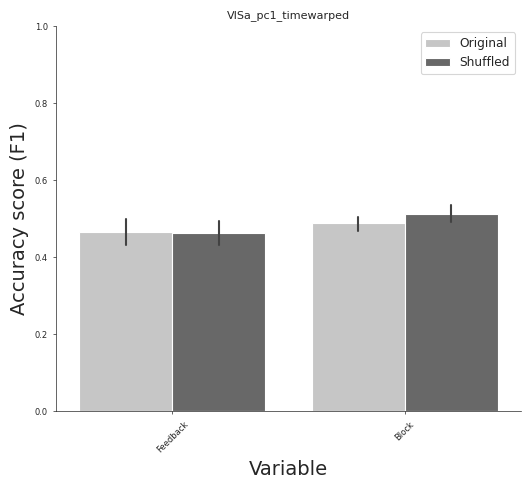

/tmp/ipykernel_25797/466659379.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


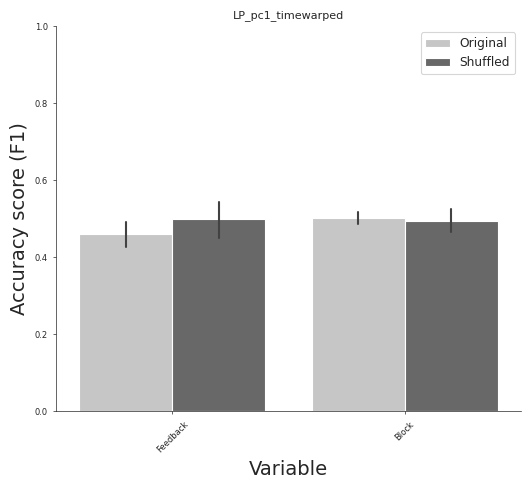

/tmp/ipykernel_25797/466659379.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


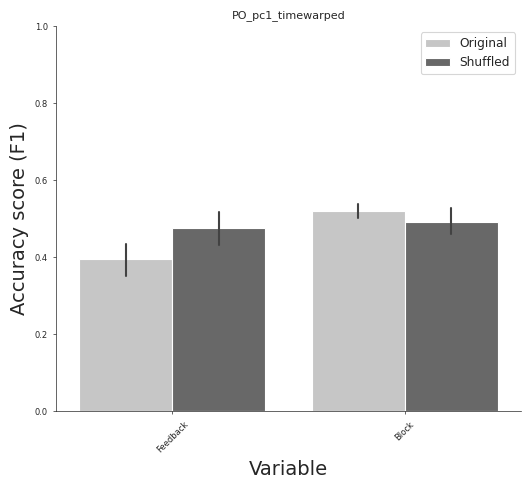

In [209]:
areas_to_analyse = all_results['area'].unique()
for a, area in enumerate(areas_to_analyse):
    use = all_results.loc[all_results['area']==area]
    pivot_decoders = pd.melt(use, id_vars=['type'], value_vars=["f1", "f1_shuffle"])
    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=[6, 5])
    sns.barplot(x='type', y='value', hue='variable',
                    data=pivot_decoders, ci=95, palette='Greys', order=['feedback','block'])
    plt.ylabel('Accuracy score (F1)', fontsize=14)
    plt.xlabel('Variable', fontsize=14)
    plt.ylim([0, 1])
    plt.xticks([0, 1], ['Feedback', 'Block'], rotation=45)
    handles, _ = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['Original', 'Shuffled'])
    sns.despine(top=True, right=True)
    plt.title(area)
    plt.show()

/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 1980 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 1980 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 1980 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


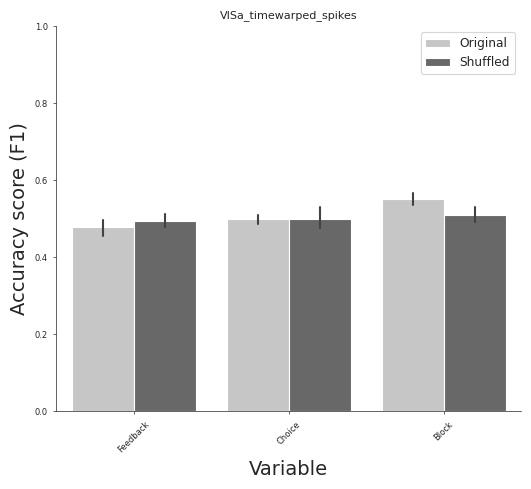

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


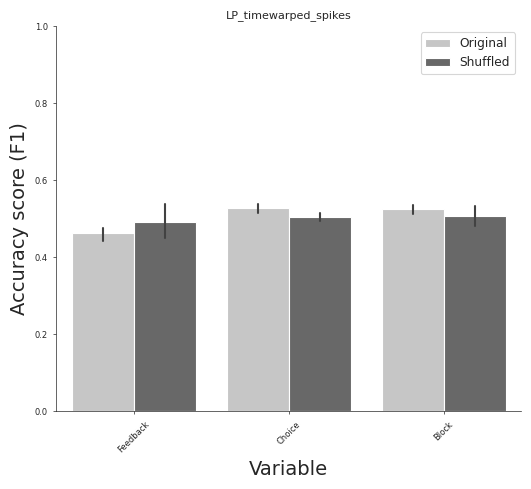

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


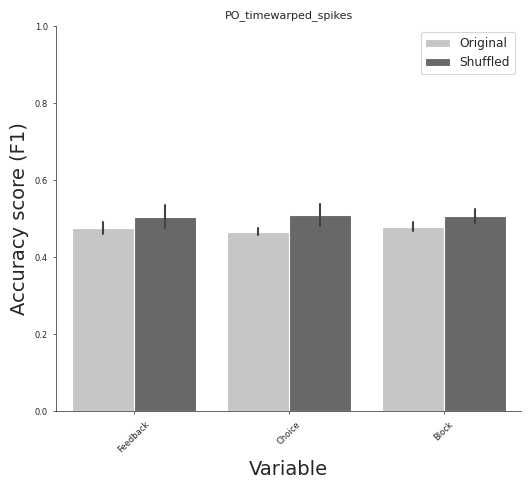

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


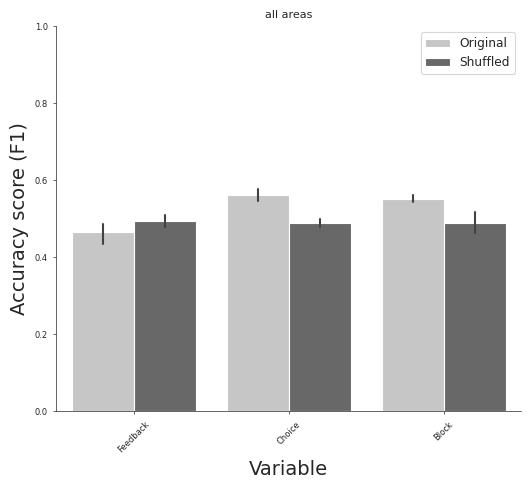

Processed session 1/89: a4a74102-2af5-45dc-9e41-ef7f5aed88be
Processed session 2/89: d57df551-6dcb-4242-9c72-b806cff5613a


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2738 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: DG
Processed 2738 samples for DG
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 2738 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2738 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


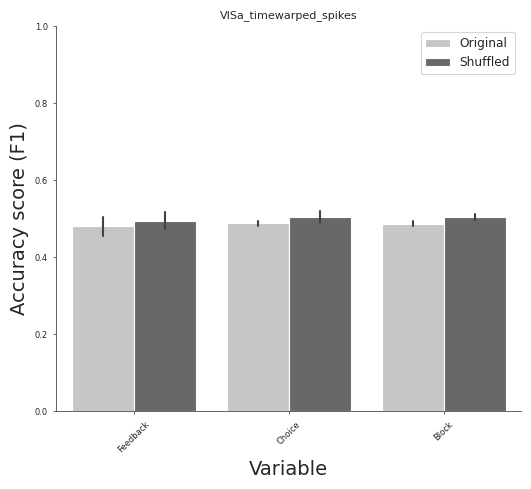

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


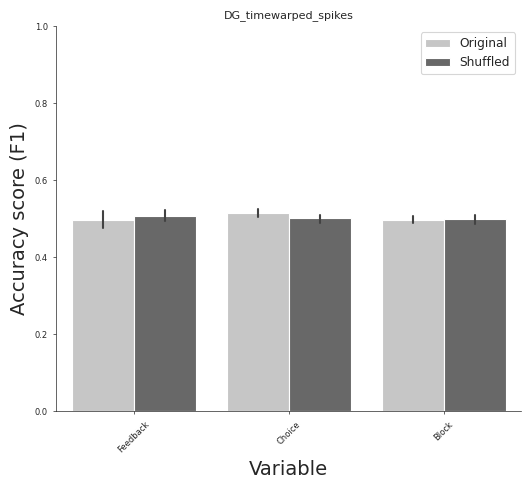

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


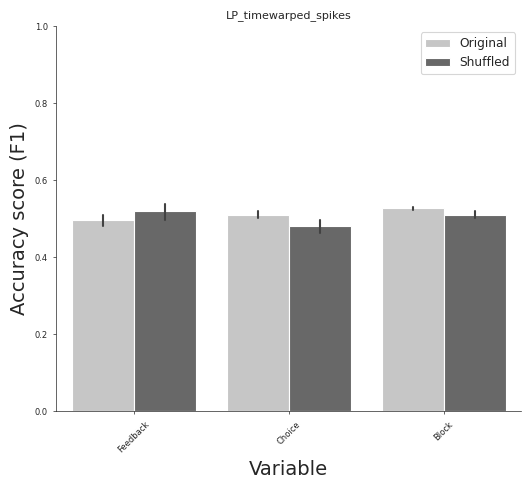

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


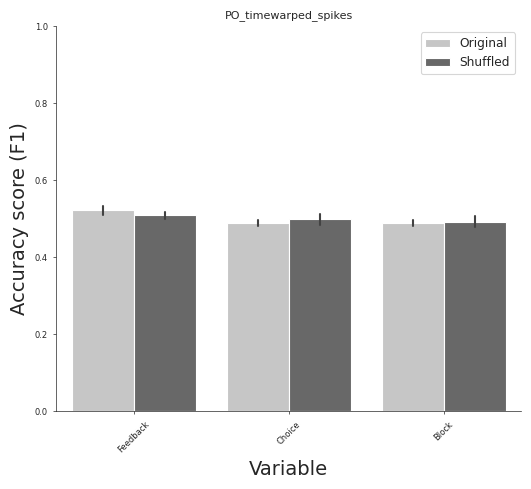

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


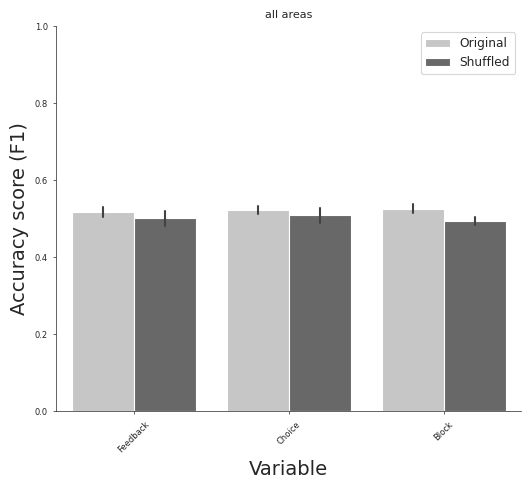

Processed session 3/89: 56b57c38-2699-4091-90a8-aba35103155e
No behavior for session 4/89: 6ab9d98c-b1e9-4574-b8fe-b9eec88097e0
Processed session 4/89: 6ab9d98c-b1e9-4574-b8fe-b9eec88097e0
Processed session 5/89: bb099402-fb31-4cfd-824e-1c97530a0875
No behavior for session 6/89: ca4ecb4c-4b60-4723-9b9e-2c54a6290a53
Processed session 6/89: ca4ecb4c-4b60-4723-9b9e-2c54a6290a53


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 3506 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 3506 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


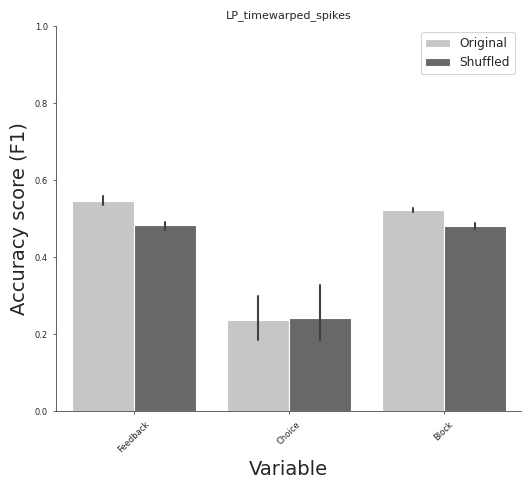

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


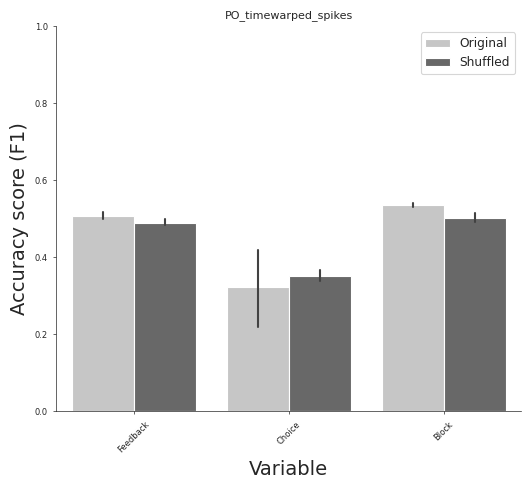

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


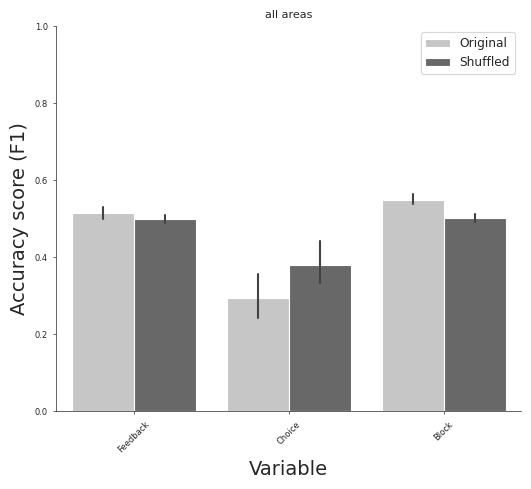

Processed session 7/89: 72cb5550-43b4-4ef0-add5-e4adfdfb5e02
No behavior for session 8/89: 0c828385-6dd6-4842-a702-c5075f5f5e81
Processed session 8/89: 0c828385-6dd6-4842-a702-c5075f5f5e81


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 3125 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 3125 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


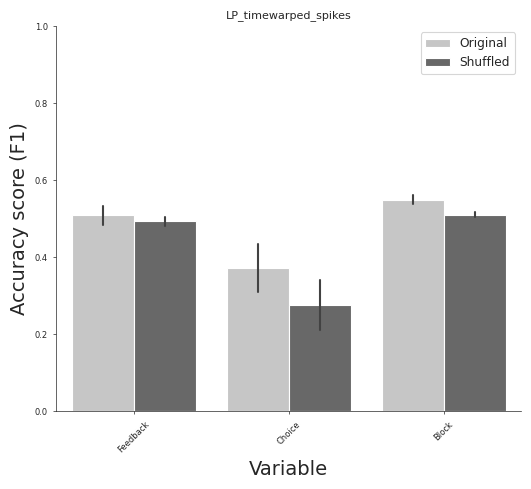

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


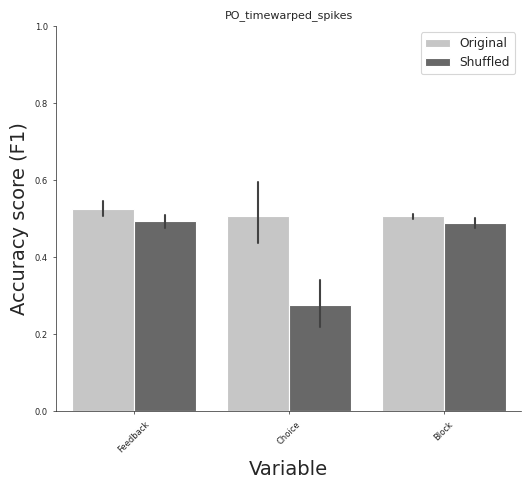

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


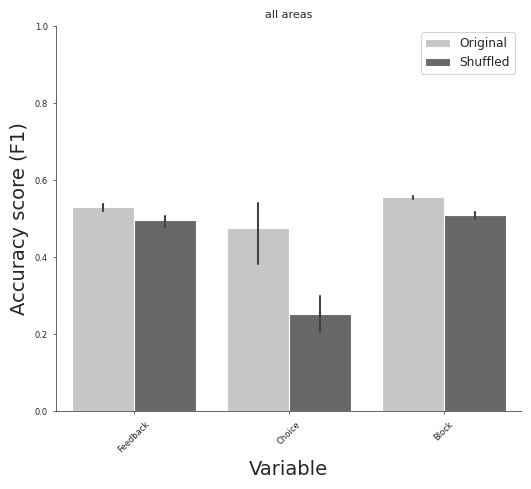

Processed session 9/89: 746d1902-fa59-4cab-b0aa-013be36060d5


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 2388 samples for LP
Unique broader labels: ['ITI' 'Pre-quiescence' 'Quiescence' 'Choice' 'Stimulus']
Processing area: PO
Processed 2388 samples for PO
Unique broader labels: ['ITI' 'Pre-quiescence' 'Quiescence' 'Choice' 'Stimulus']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


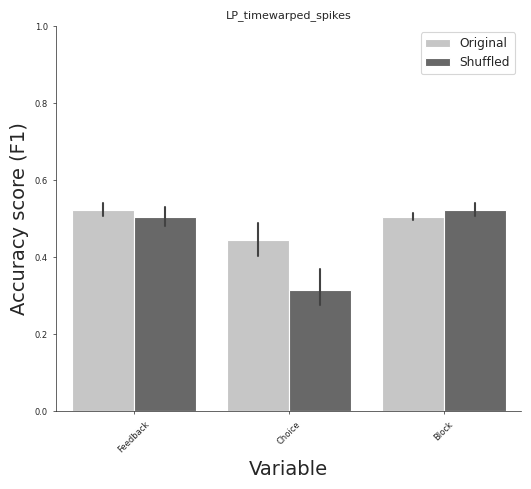

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


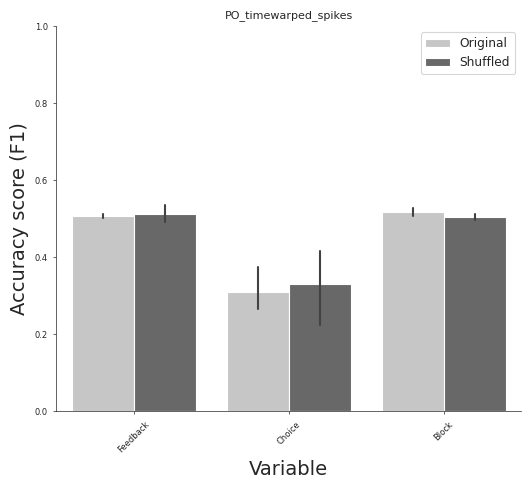

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


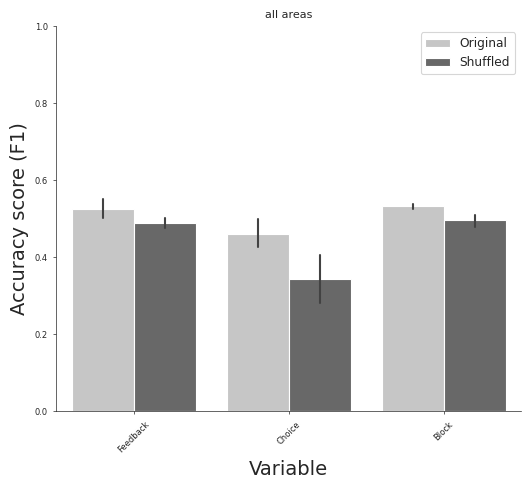

Processed session 10/89: dac3a4c1-b666-4de0-87e8-8c514483cacf
No behavior for session 11/89: caa5dddc-9290-4e27-9f5e-575ba3598614
Processed session 11/89: caa5dddc-9290-4e27-9f5e-575ba3598614


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2564 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


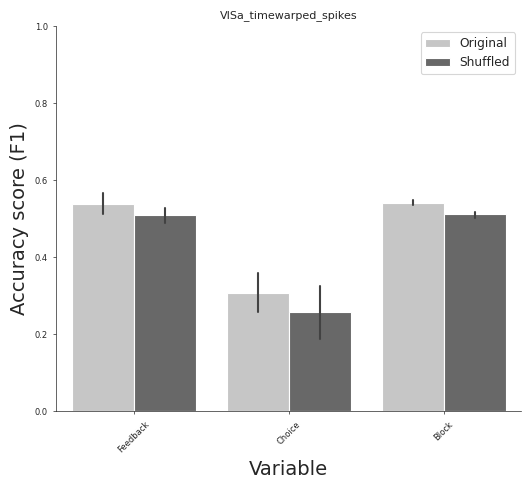

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


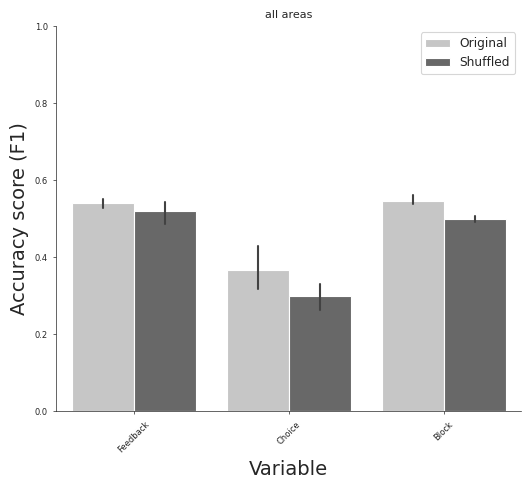

Processed session 12/89: a8a8af78-16de-4841-ab07-fde4b5281a03
No behavior for session 13/89: f115196e-8dfe-4d2a-8af3-8206d93c1729
Processed session 13/89: f115196e-8dfe-4d2a-8af3-8206d93c1729
No behavior for session 14/89: 0a018f12-ee06-4b11-97aa-bbbff5448e9f
Processed session 14/89: 0a018f12-ee06-4b11-97aa-bbbff5448e9f


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 3183 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 3183 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


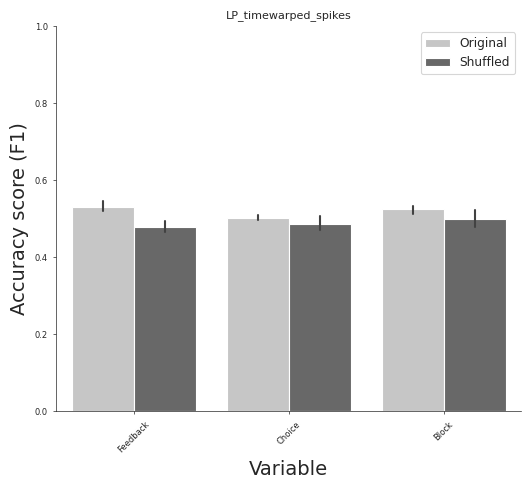

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


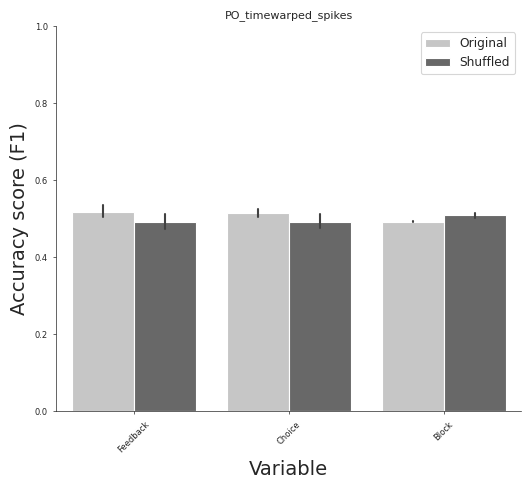

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


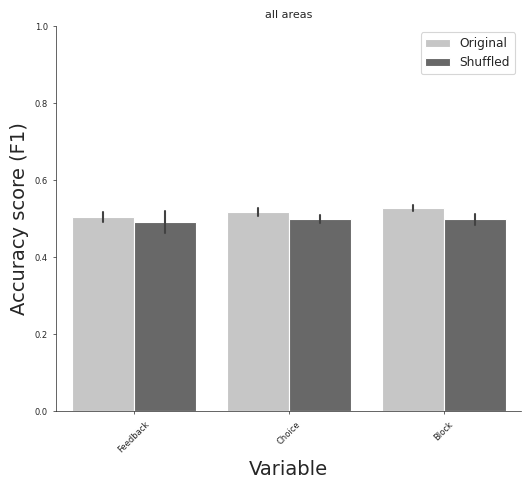

Processed session 15/89: d2832a38-27f6-452d-91d6-af72d794136c


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 2627 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2627 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


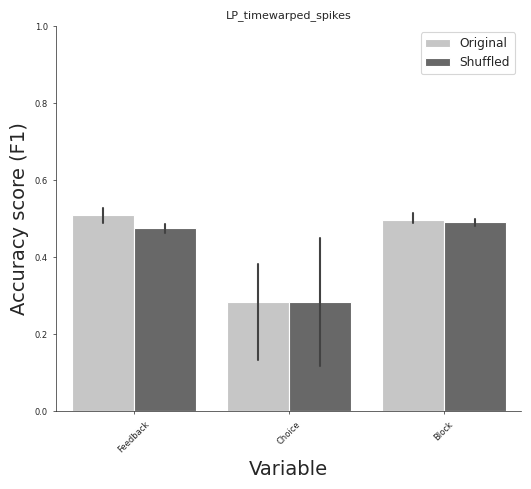

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


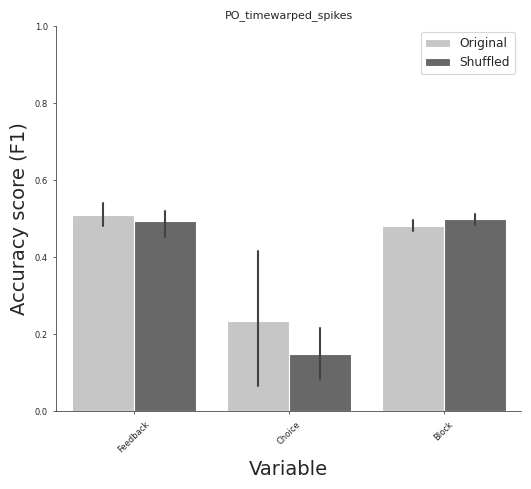

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


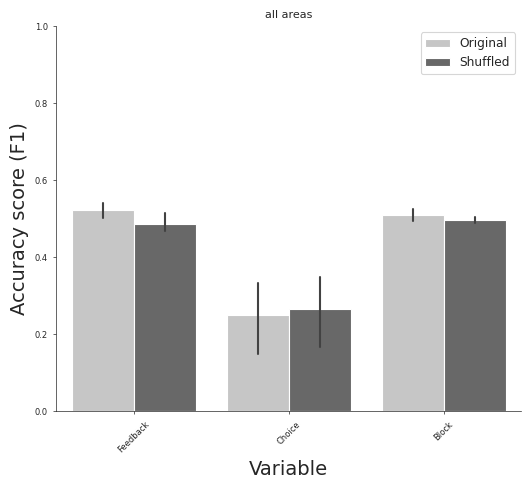

Processed session 16/89: 6f09ba7e-e3ce-44b0-932b-c003fb44fb89
No behavior for session 17/89: b196a2ad-511b-4e90-ac99-b5a29ad25c22
Processed session 17/89: b196a2ad-511b-4e90-ac99-b5a29ad25c22
Processed session 18/89: 73918ae1-e4fd-4c18-b132-00cb555b1ad2


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2981 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 2981 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2981 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


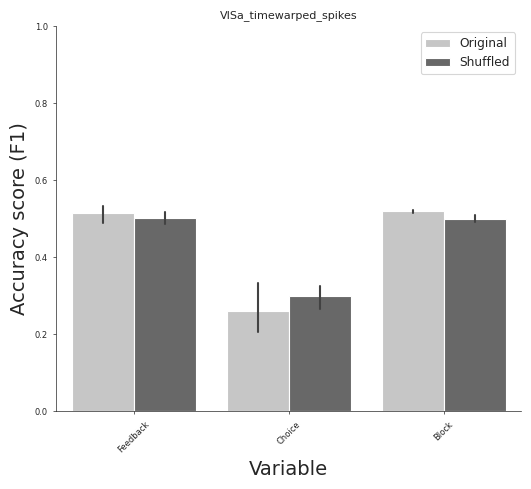

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


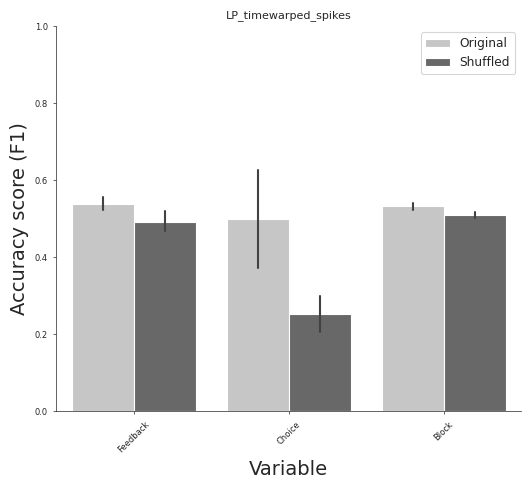

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


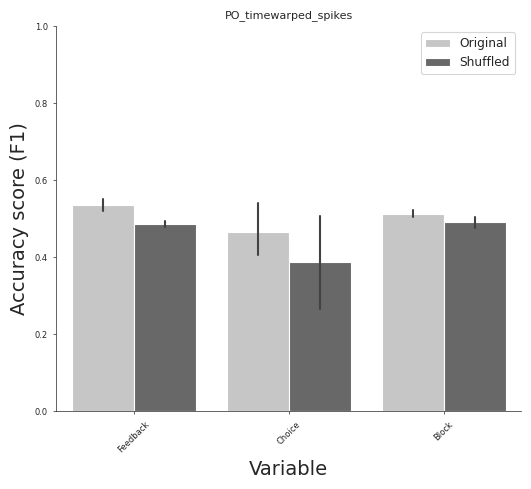

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


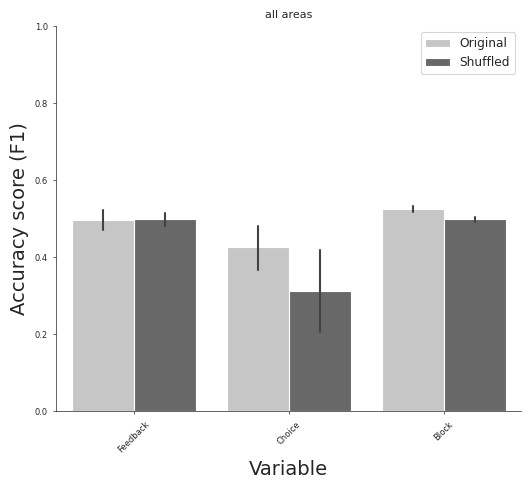

Processed session 19/89: f312aaec-3b6f-44b3-86b4-3a0c119c0438


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 3467 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


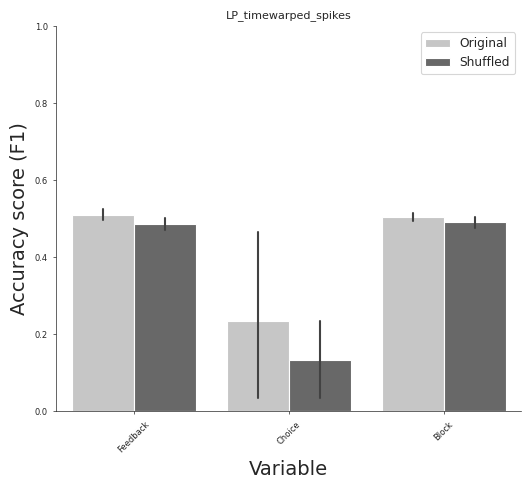

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


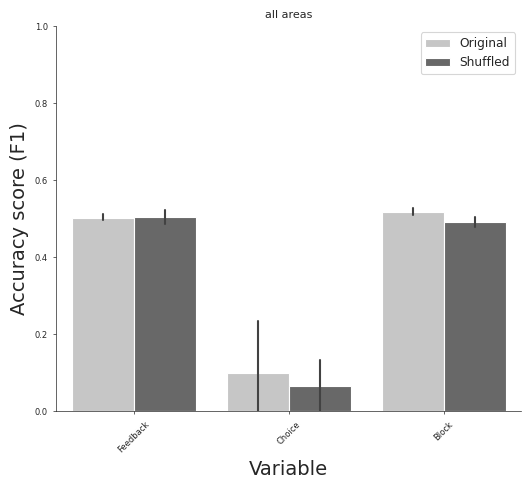

Processed session 20/89: dda5fc59-f09a-4256-9fb5-66c67667a466
No behavior for session 21/89: ebce500b-c530-47de-8cb1-963c552703ea
Processed session 21/89: ebce500b-c530-47de-8cb1-963c552703ea


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 4549 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: CA1
Processed 4549 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: DG
Processed 4549 samples for DG
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 4549 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 4549 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


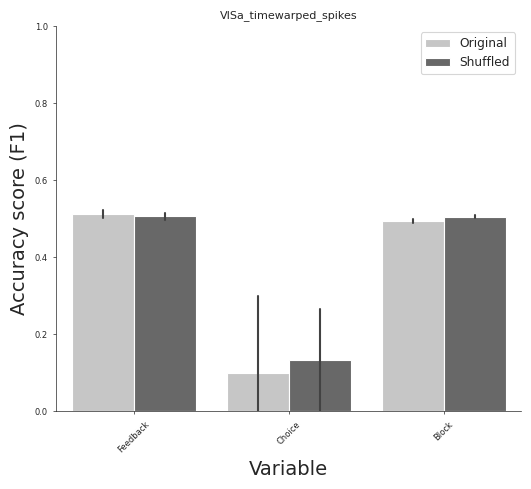

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


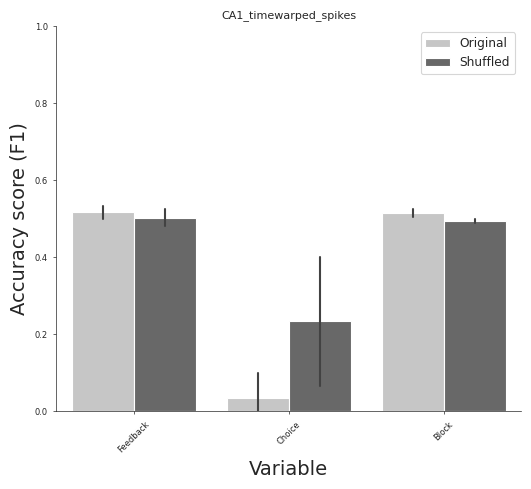

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


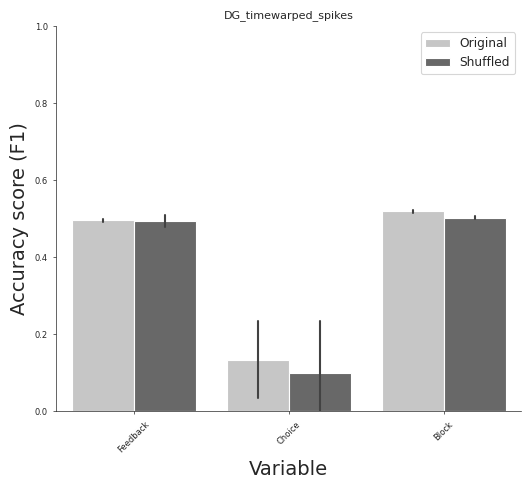

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


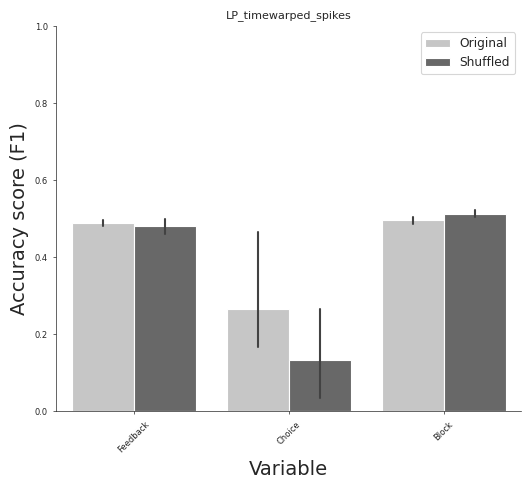

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


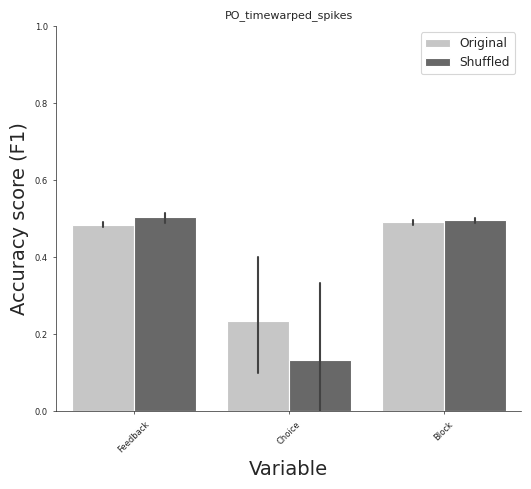

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


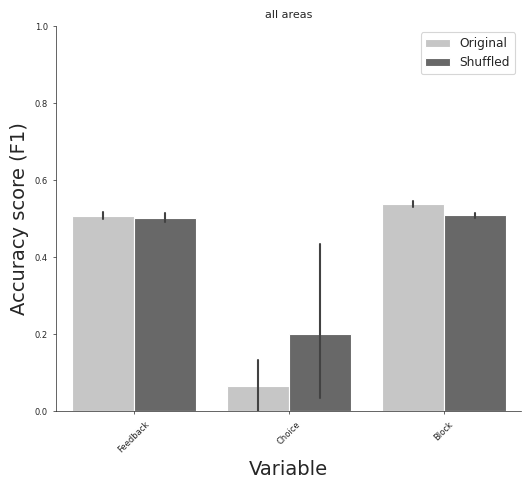

Processed session 22/89: ee40aece-cffd-4edb-a4b6-155f158c666a
No behavior for session 23/89: 614e1937-4b24-4ad3-9055-c8253d089919
Processed session 23/89: 614e1937-4b24-4ad3-9055-c8253d089919
Processed session 24/89: 5c0c560e-9e1f-45e9-b66e-e4ee7855be84


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 3905 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


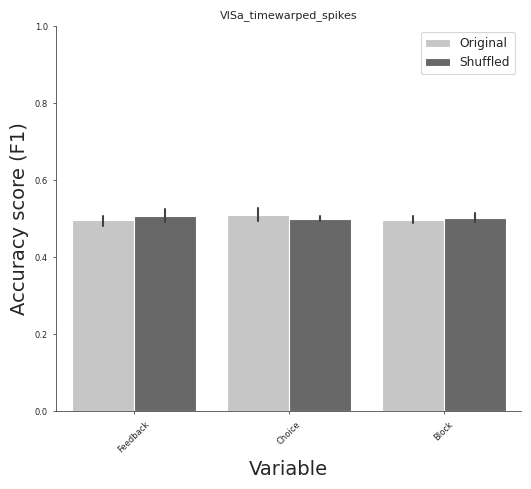

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


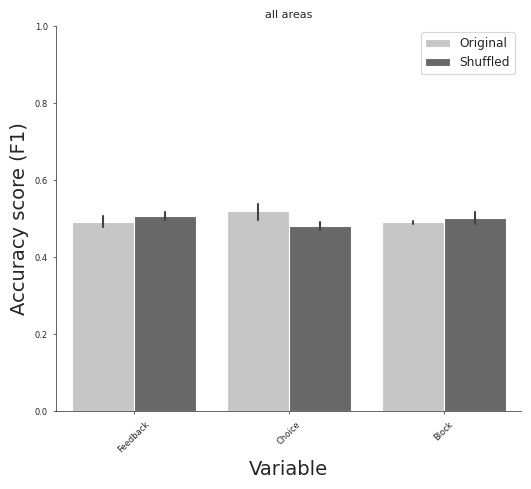

Processed session 25/89: 4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b
No behavior for session 26/89: 61e11a11-ab65-48fb-ae08-3cb80662e5d6
Processed session 26/89: 61e11a11-ab65-48fb-ae08-3cb80662e5d6


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2348 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


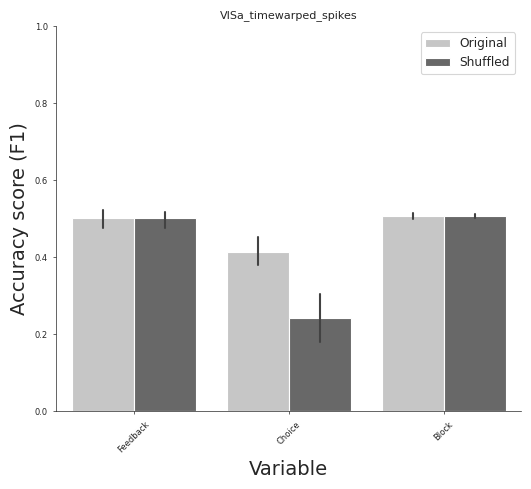

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


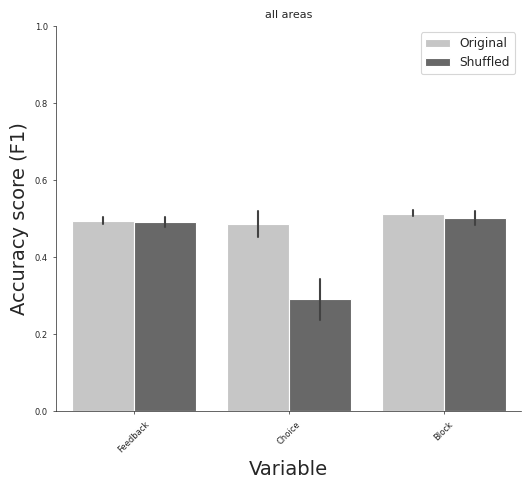

Processed session 27/89: ecb5520d-1358-434c-95ec-93687ecd1396


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2938 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 2938 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


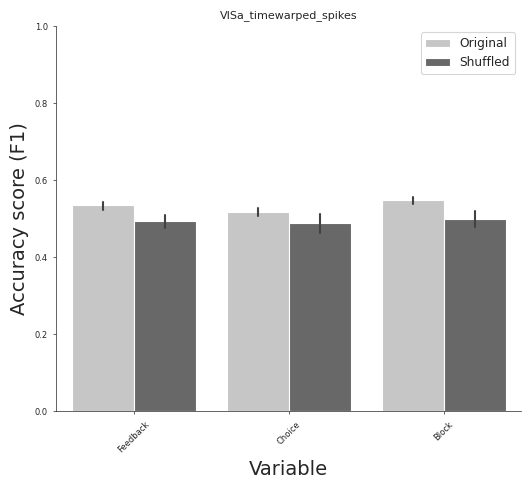

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


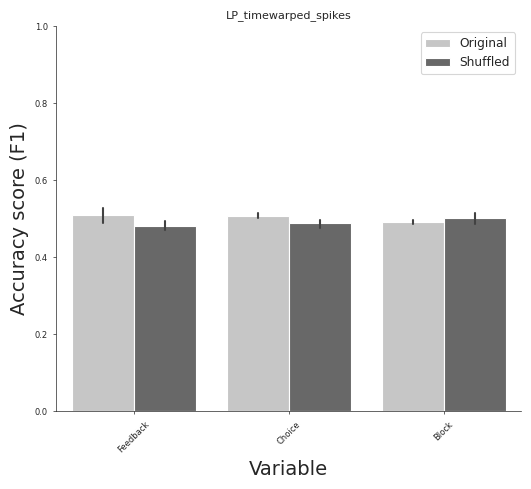

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


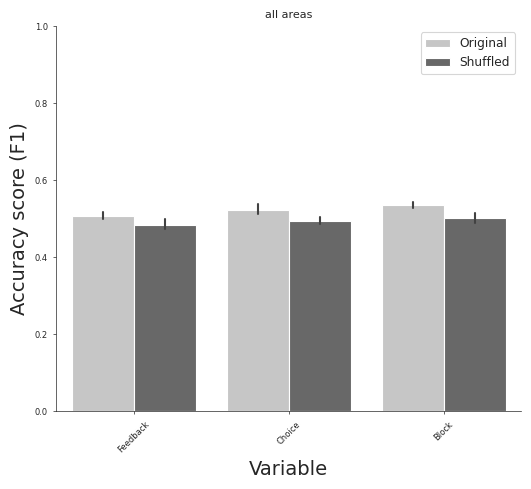

Processed session 28/89: 54238fd6-d2d0-4408-b1a9-d19d24fd29ce
No behavior for session 29/89: e45481fa-be22-4365-972c-e7404ed8ab5a
Processed session 29/89: e45481fa-be22-4365-972c-e7404ed8ab5a
Processed session 30/89: e535fb62-e245-4a48-b119-88ce62a6fe67
No behavior for session 31/89: a66f1593-dafd-4982-9b66-f9554b6c86b5
Processed session 31/89: a66f1593-dafd-4982-9b66-f9554b6c86b5


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 2296 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2296 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


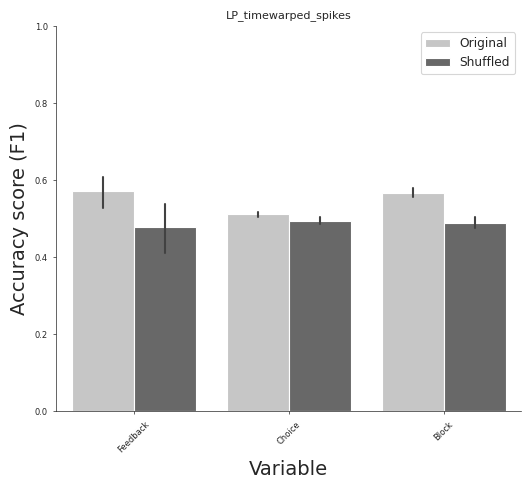

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


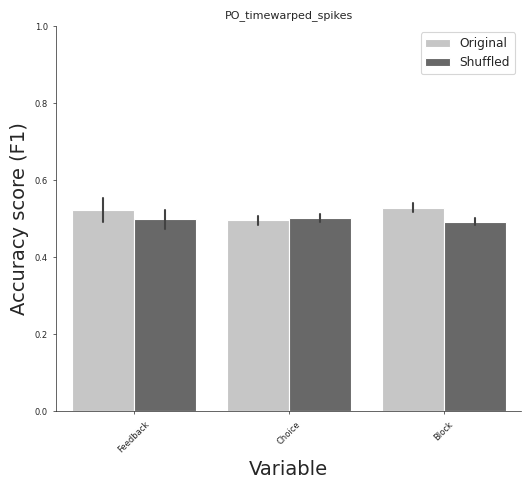

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


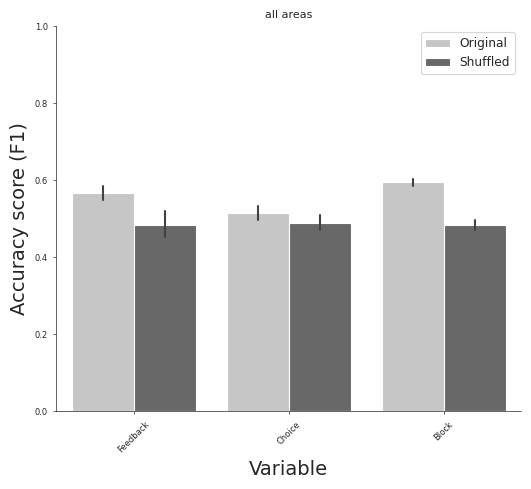

Processed session 32/89: 51e53aff-1d5d-4182-a684-aba783d50ae5
No behavior for session 33/89: 0cad7ea8-8e6c-4ad1-a5c5-53fbb2df1a63
Processed session 33/89: 0cad7ea8-8e6c-4ad1-a5c5-53fbb2df1a63


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 3401 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


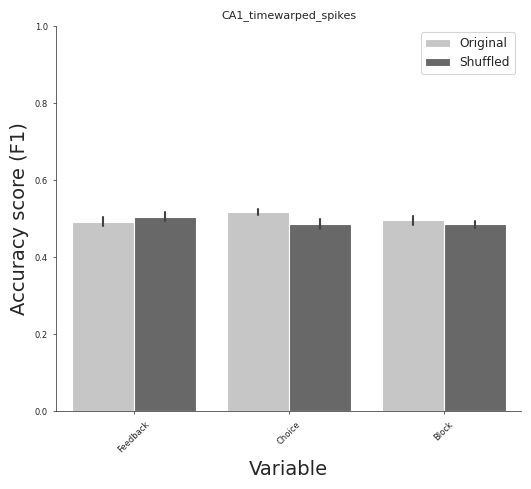

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


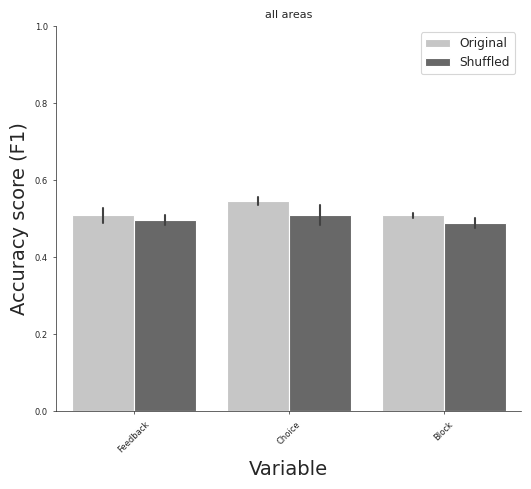

Processed session 34/89: 111c1762-7908-47e0-9f40-2f2ee55b6505


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 2017 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2017 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


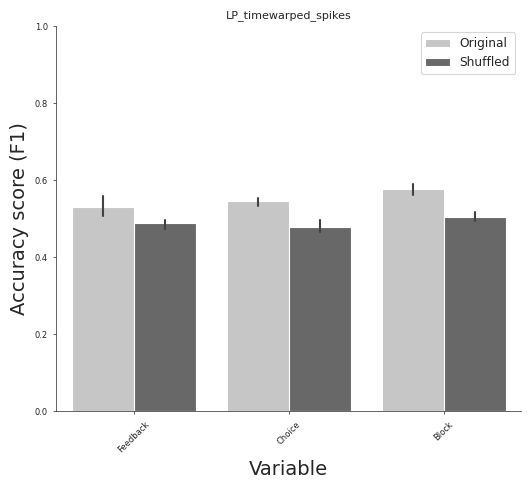

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


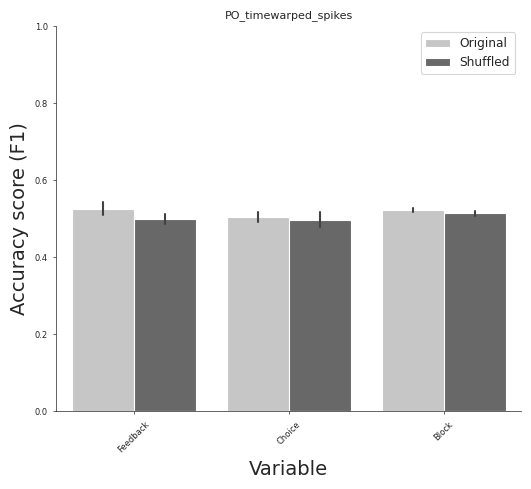

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


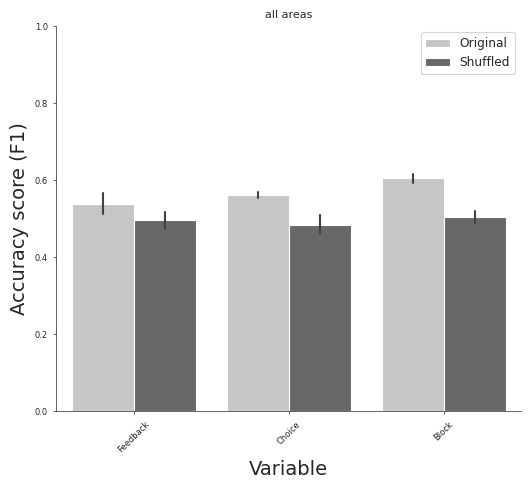

Processed session 35/89: 0802ced5-33a3-405e-8336-b65ebc5cb07c
No behavior for session 36/89: b03fbc44-3d8e-4a6c-8a50-5ea3498568e0
Processed session 36/89: b03fbc44-3d8e-4a6c-8a50-5ea3498568e0
No behavior for session 37/89: 3f859b5c-e73a-4044-b49e-34bb81e96715
Processed session 37/89: 3f859b5c-e73a-4044-b49e-34bb81e96715


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 1934 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 1934 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


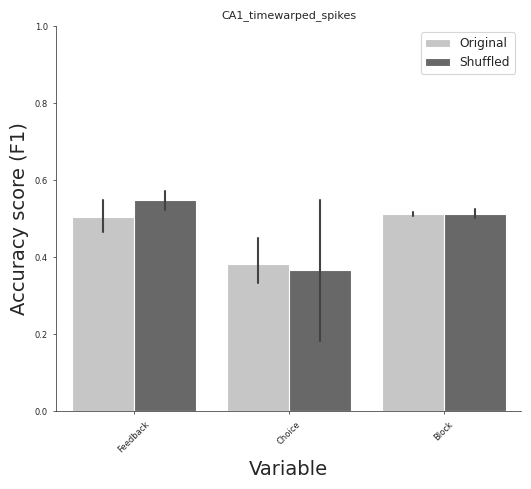

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


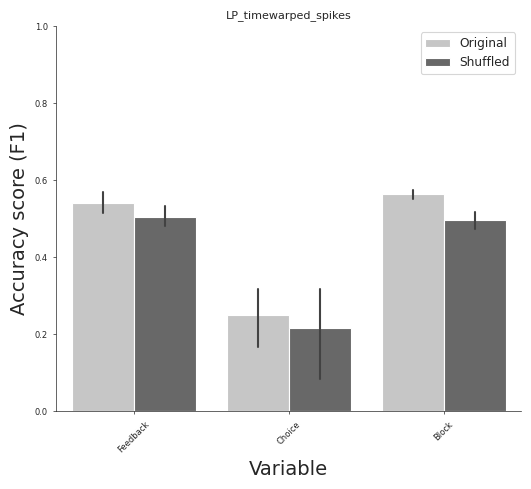

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


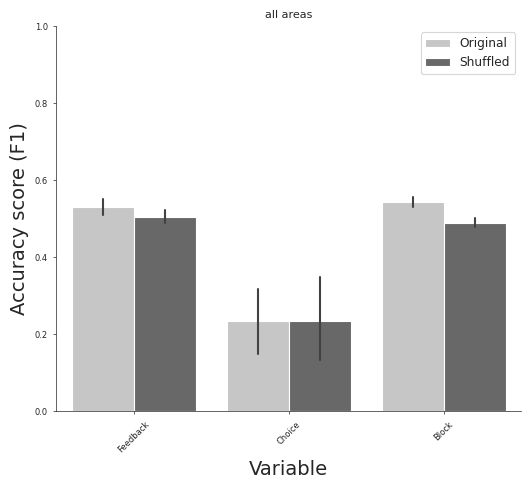

Processed session 38/89: db4df448-e449-4a6f-a0e7-288711e7a75a
No behavior for session 39/89: 8928f98a-b411-497e-aa4b-aa752434686d
Processed session 39/89: 8928f98a-b411-497e-aa4b-aa752434686d
No behavior for session 40/89: 3bcb81b4-d9ca-4fc9-a1cd-353a966239ca
Processed session 40/89: 3bcb81b4-d9ca-4fc9-a1cd-353a966239ca
Processed session 41/89: 7cb81727-2097-4b52-b480-c89867b5b34c
No behavior for session 42/89: 30c4e2ab-dffc-499d-aae4-e51d6b3218c2
Processed session 42/89: 30c4e2ab-dffc-499d-aae4-e51d6b3218c2
No behavior for session 43/89: 71e55bfe-5a3a-4cba-bdc7-f085140d798e
Processed session 43/89: 71e55bfe-5a3a-4cba-bdc7-f085140d798e
No behavior for session 44/89: d04feec7-d0b7-4f35-af89-0232dd975bf0
Processed session 44/89: d04feec7-d0b7-4f35-af89-0232dd975bf0


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 3661 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


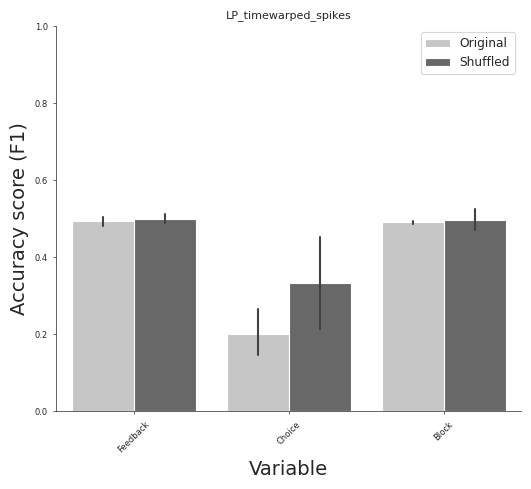

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


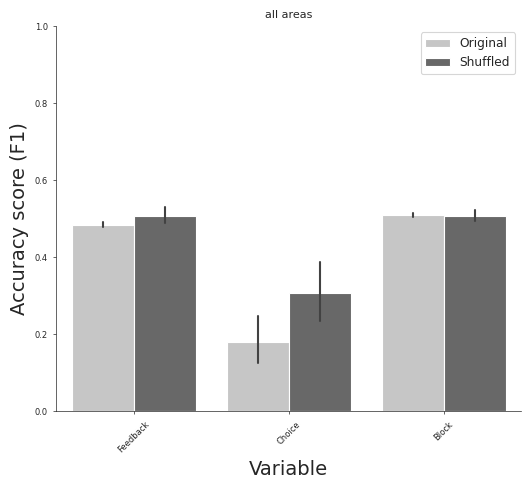

Processed session 45/89: 824cf03d-4012-4ab1-b499-c83a92c5589e
No behavior for session 46/89: 5ae68c54-2897-4d3a-8120-426150704385
Processed session 46/89: 5ae68c54-2897-4d3a-8120-426150704385
No behavior for session 47/89: 57fd2325-67f4-4d45-9907-29e77d3043d7
Processed session 47/89: 57fd2325-67f4-4d45-9907-29e77d3043d7
No behavior for session 48/89: 41872d7f-75cb-4445-bb1a-132b354c44f0
Processed session 48/89: 41872d7f-75cb-4445-bb1a-132b354c44f0
No behavior for session 49/89: c7bf2d49-4937-4597-b307-9f39cb1c7b16
Processed session 49/89: c7bf2d49-4937-4597-b307-9f39cb1c7b16


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2295 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: CA1
Processed 2295 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: DG
Processed 2295 samples for DG
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 2295 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


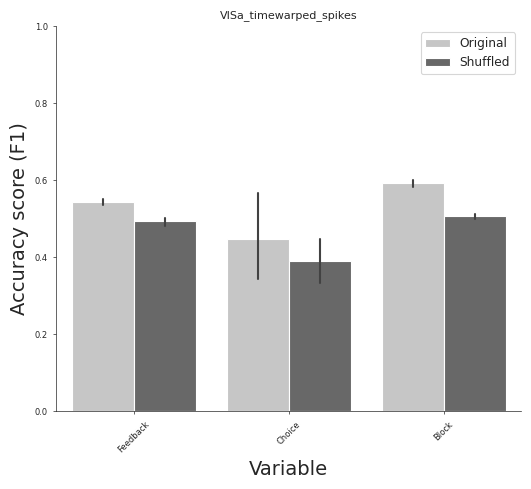

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


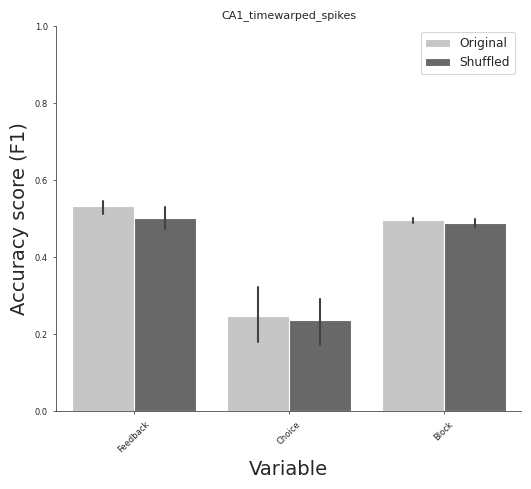

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


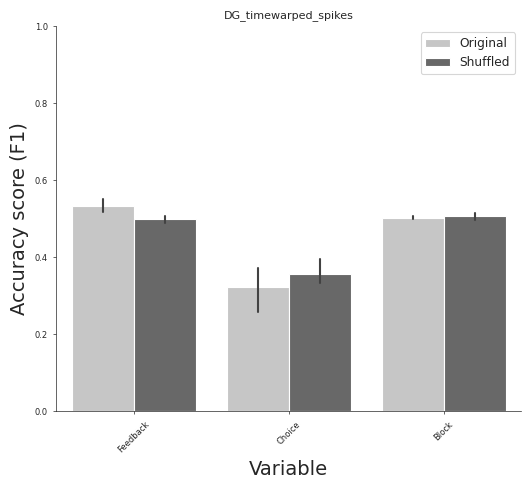

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


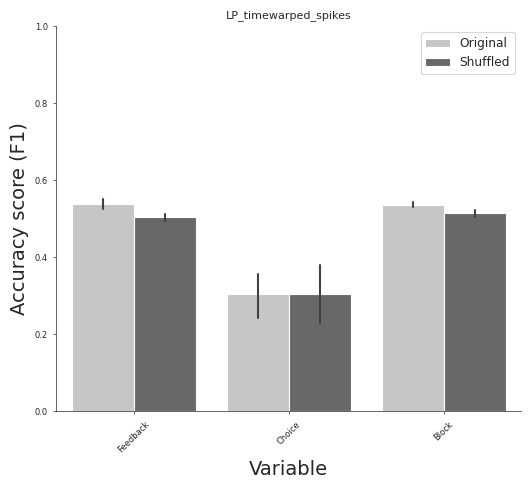

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


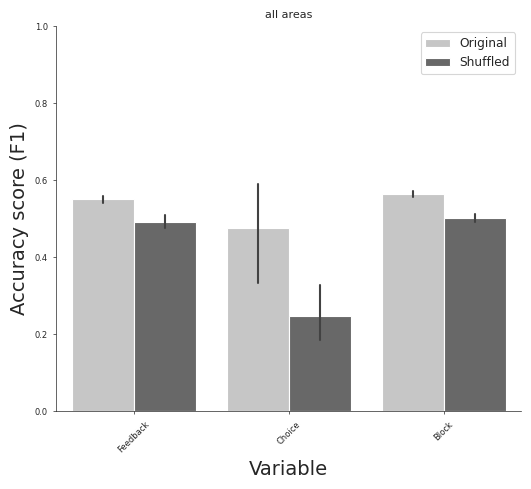

Processed session 50/89: e2b845a1-e313-4a08-bc61-a5f662ed295e


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 1933 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: CA1
Processed 1933 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


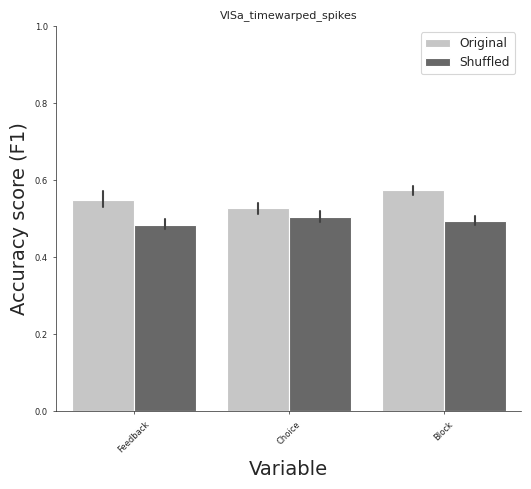

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


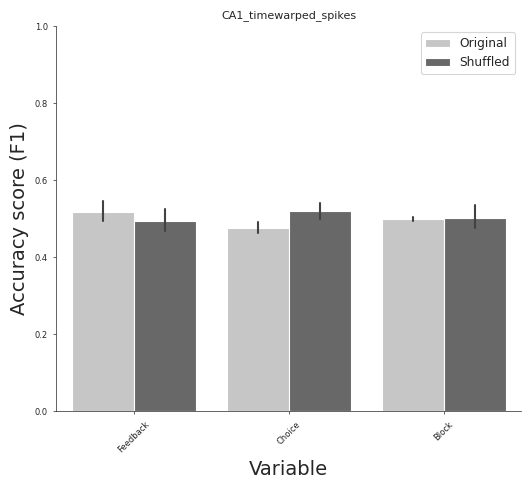

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


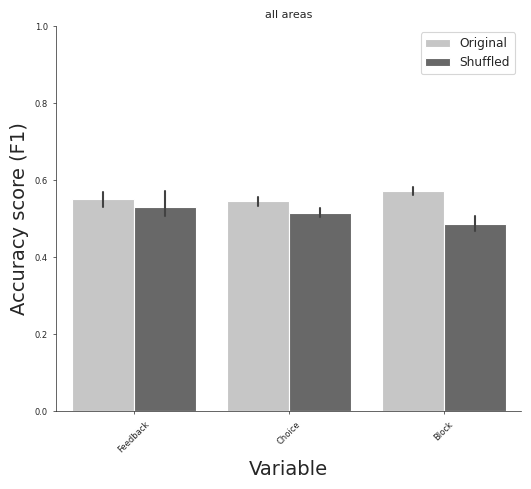

Processed session 51/89: 4a45c8ba-db6f-4f11-9403-56e06a33dfa4
No behavior for session 52/89: 7af49c00-63dd-4fed-b2e0-1b3bd945b20b
Processed session 52/89: 7af49c00-63dd-4fed-b2e0-1b3bd945b20b


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 4330 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 4330 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


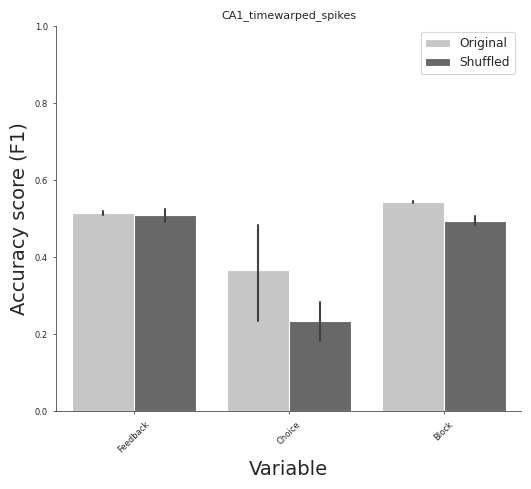

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


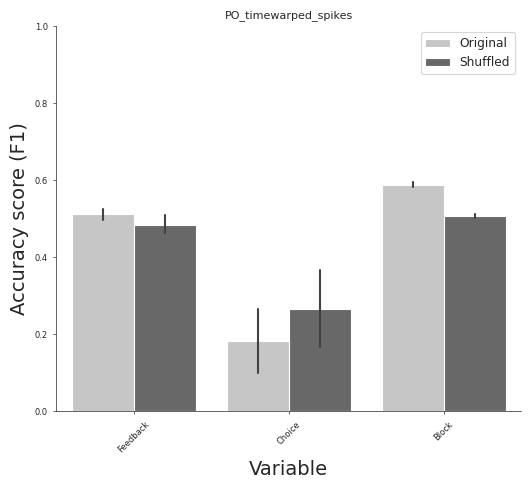

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


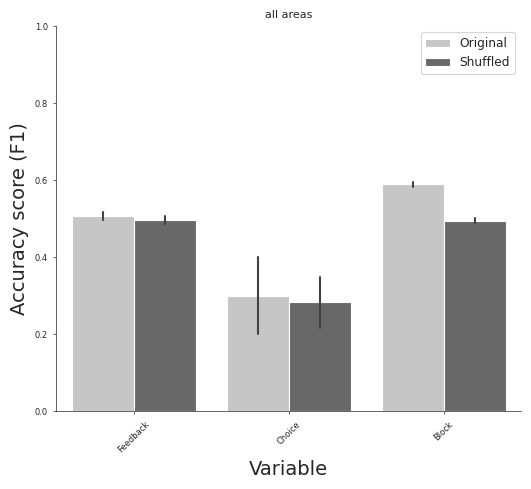

Processed session 53/89: 15763234-d21e-491f-a01b-1238eb96d389
No behavior for session 54/89: 781b35fd-e1f0-4d14-b2bb-95b7263082bb
Processed session 54/89: 781b35fd-e1f0-4d14-b2bb-95b7263082bb
No behavior for session 55/89: 754b74d5-7a06-4004-ae0c-72a10b6ed2e6
Processed session 55/89: 754b74d5-7a06-4004-ae0c-72a10b6ed2e6


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 3817 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


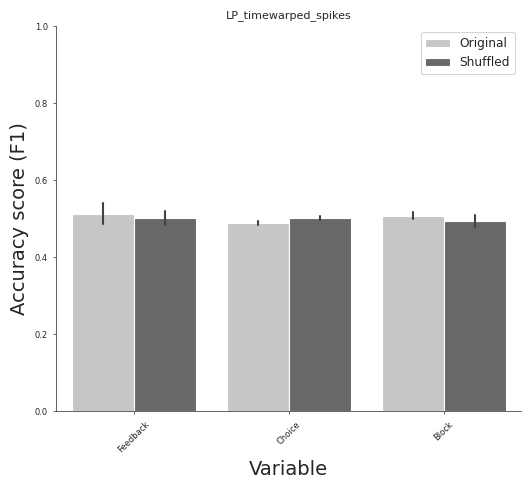

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


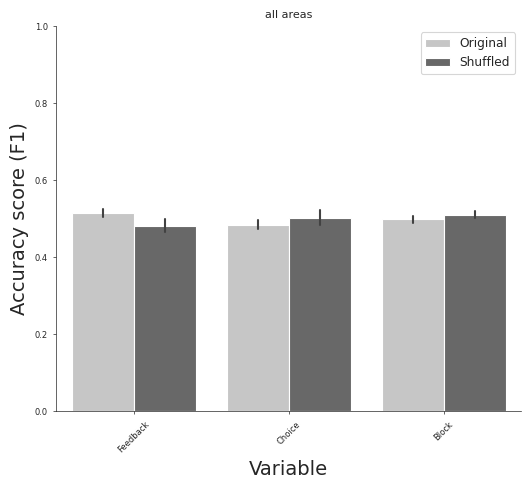

Processed session 56/89: 4b00df29-3769-43be-bb40-128b1cba6d35
No behavior for session 57/89: f140a2ec-fd49-4814-994a-fe3476f14e66
Processed session 57/89: f140a2ec-fd49-4814-994a-fe3476f14e66


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISam
Processed 2060 samples for VISam
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: CA1
Processed 2060 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


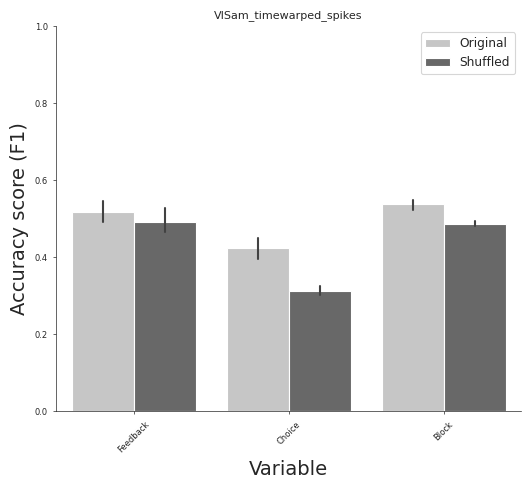

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


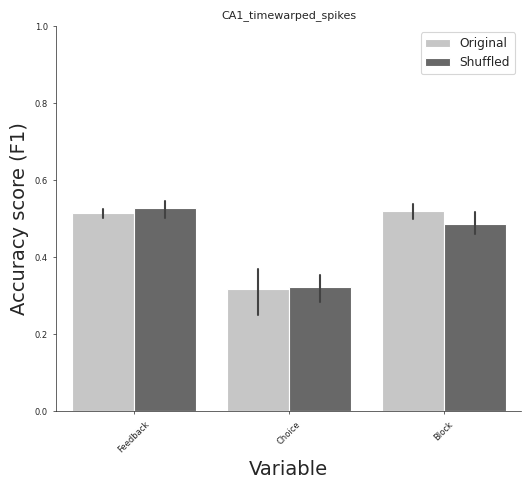

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


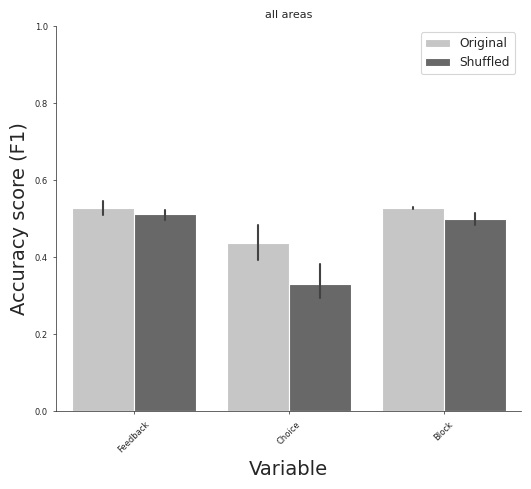

Processed session 58/89: 687017d4-c9fc-458f-a7d5-0979fe1a7470
No behavior for session 59/89: 03cf52f6-fba6-4743-a42e-dd1ac3072343
Processed session 59/89: 03cf52f6-fba6-4743-a42e-dd1ac3072343
No behavior for session 60/89: 862ade13-53cd-4221-a3fa-dda8643641f2
Processed session 60/89: 862ade13-53cd-4221-a3fa-dda8643641f2


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 3337 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


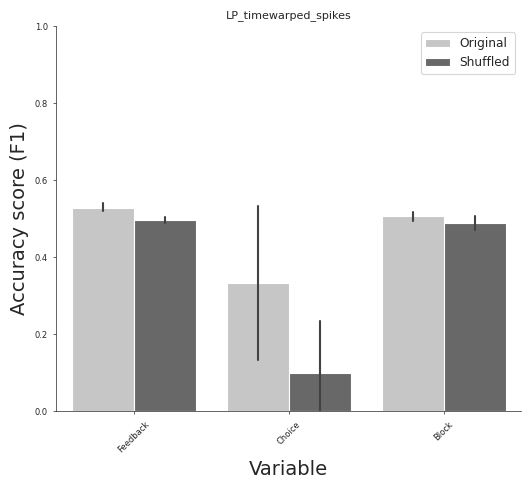

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


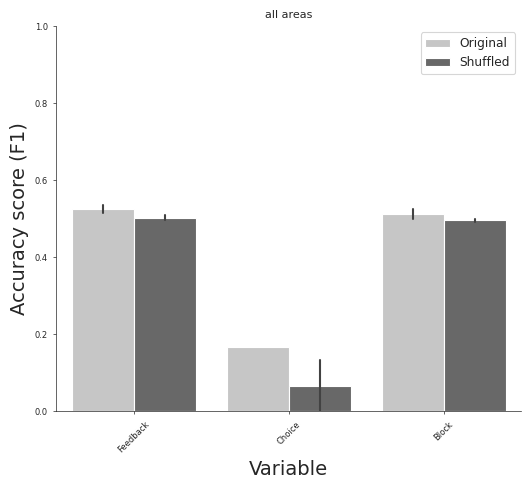

Processed session 61/89: 3638d102-e8b6-4230-8742-e548cd87a949
No behavior for session 62/89: c7248e09-8c0d-40f2-9eb4-700a8973d8c8
Processed session 62/89: c7248e09-8c0d-40f2-9eb4-700a8973d8c8
No behavior for session 63/89: e9b57a5a-b06d-476d-ad20-7ec42a16f5f5
Processed session 63/89: e9b57a5a-b06d-476d-ad20-7ec42a16f5f5
No behavior for session 64/89: 6899a67d-2e53-4215-a52a-c7021b5da5d4
Processed session 64/89: 6899a67d-2e53-4215-a52a-c7021b5da5d4
No behavior for session 65/89: 15b69921-d471-4ded-8814-2adad954bcd8
Processed session 65/89: 15b69921-d471-4ded-8814-2adad954bcd8


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2758 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: CA1
Processed 2758 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


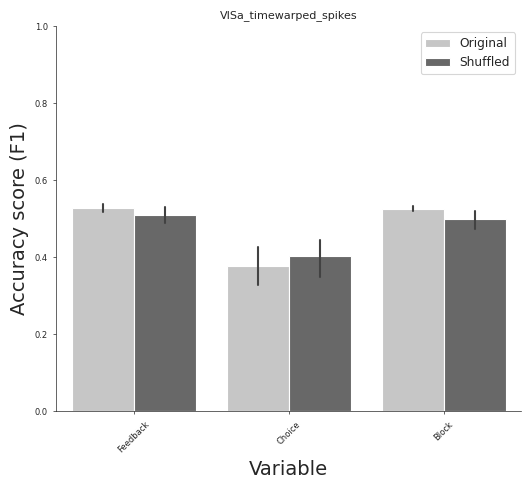

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


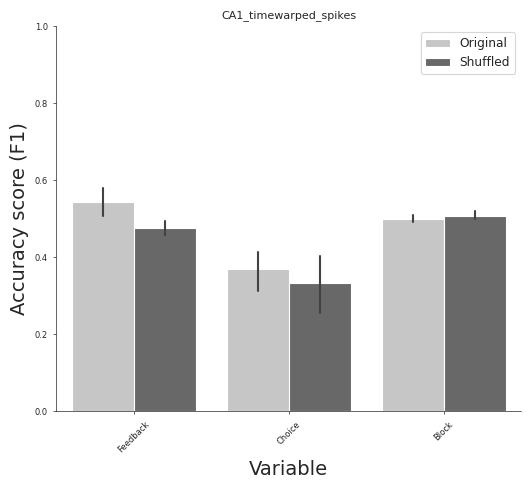

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


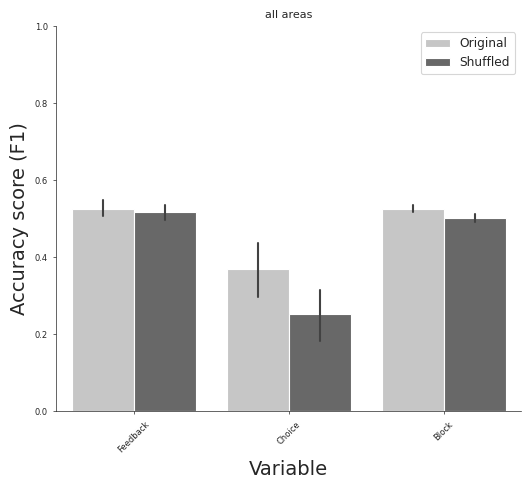

Processed session 66/89: 2bdf206a-820f-402f-920a-9e86cd5388a4
No behavior for session 67/89: d9f0c293-df4c-410a-846d-842e47c6b502
Processed session 67/89: d9f0c293-df4c-410a-846d-842e47c6b502


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 2178 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2178 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


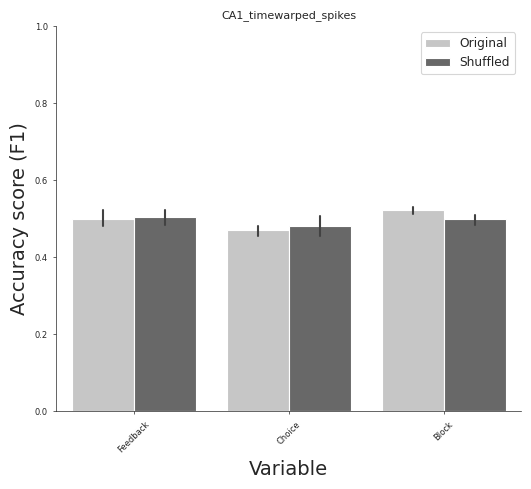

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


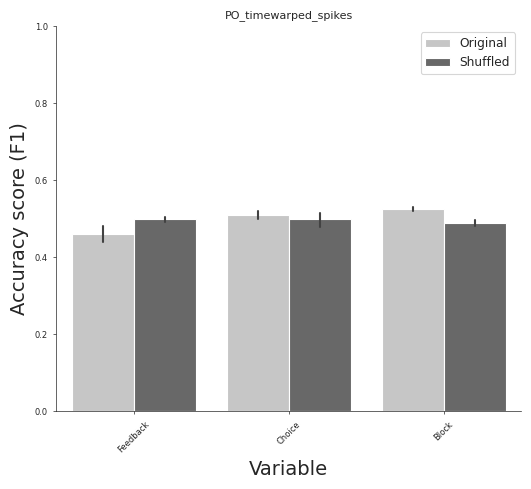

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


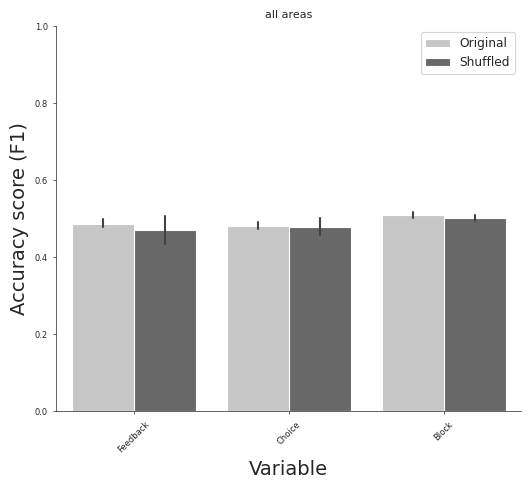

Processed session 68/89: 88224abb-5746-431f-9c17-17d7ef806e6a
No behavior for session 69/89: aad23144-0e52-4eac-80c5-c4ee2decb198
Processed session 69/89: aad23144-0e52-4eac-80c5-c4ee2decb198


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: DG
Processed 2682 samples for DG
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 2682 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2682 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


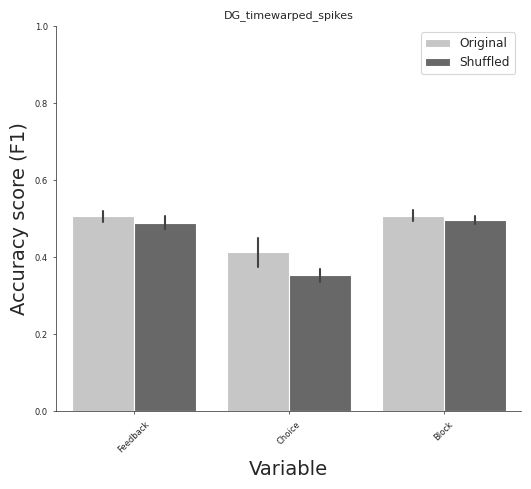

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


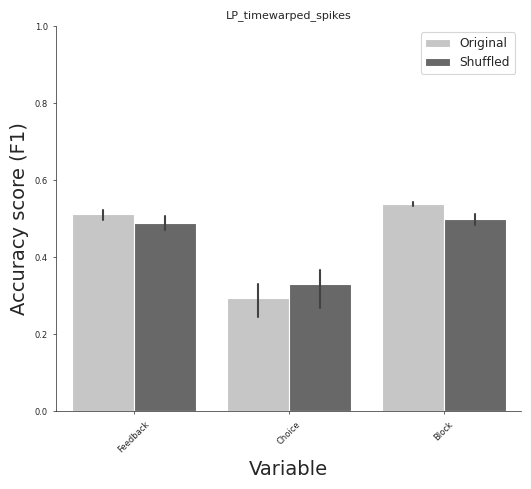

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


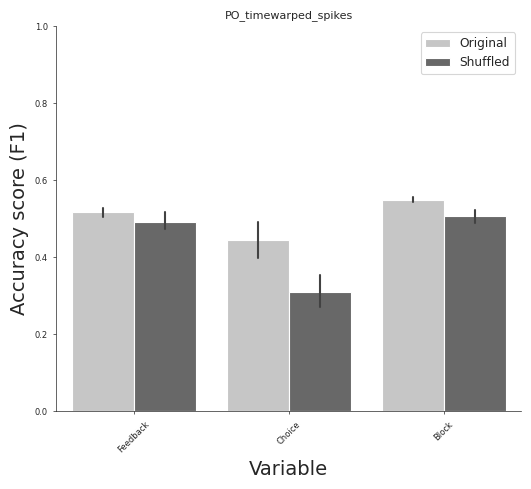

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


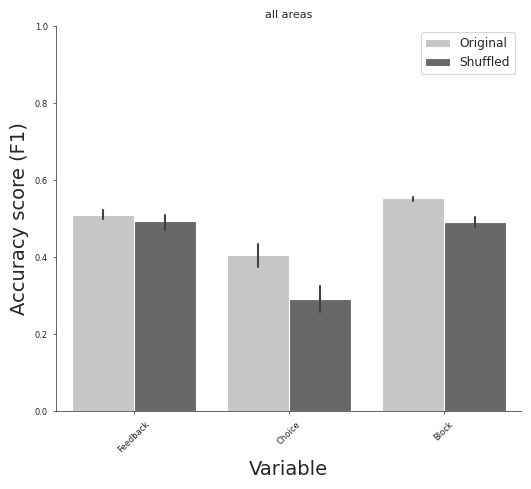

Processed session 70/89: d0ea3148-948d-4817-94f8-dcaf2342bbbe
No behavior for session 71/89: b22f694e-4a34-4142-ab9d-2556c3487086
Processed session 71/89: b22f694e-4a34-4142-ab9d-2556c3487086
No behavior for session 72/89: ebe090af-5922-4fcd-8fc6-17b8ba7bad6d
Processed session 72/89: ebe090af-5922-4fcd-8fc6-17b8ba7bad6d
No behavior for session 73/89: 642c97ea-fe89-4ec9-8629-5e492ea4019d
Processed session 73/89: 642c97ea-fe89-4ec9-8629-5e492ea4019d


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: LP
Processed 2023 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 2023 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


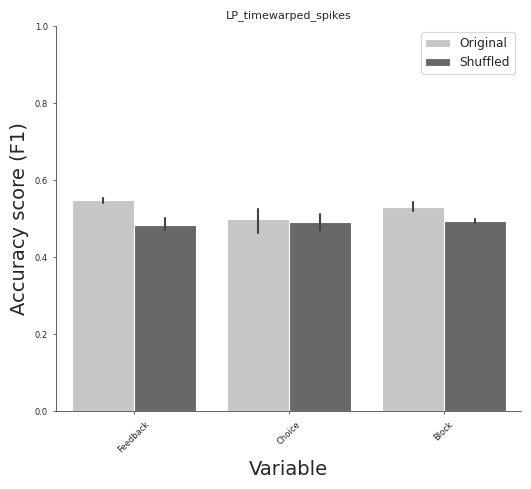

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


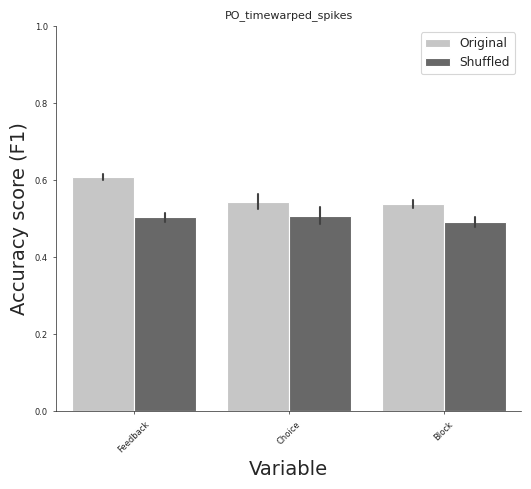

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


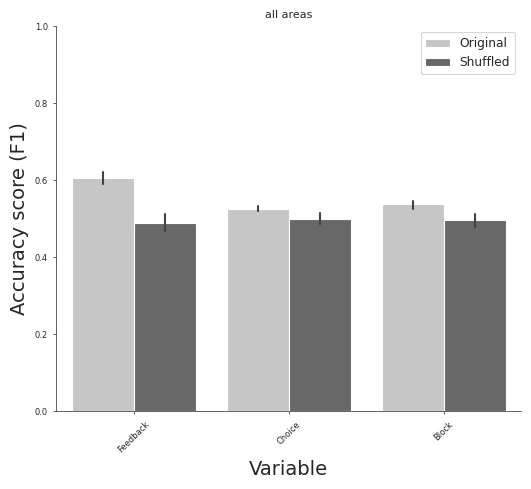

Processed session 74/89: ff96bfe1-d925-4553-94b5-bf8297adf259
No behavior for session 75/89: 572a95d1-39ca-42e1-8424-5c9ffcb2df87
Processed session 75/89: 572a95d1-39ca-42e1-8424-5c9ffcb2df87


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 3996 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


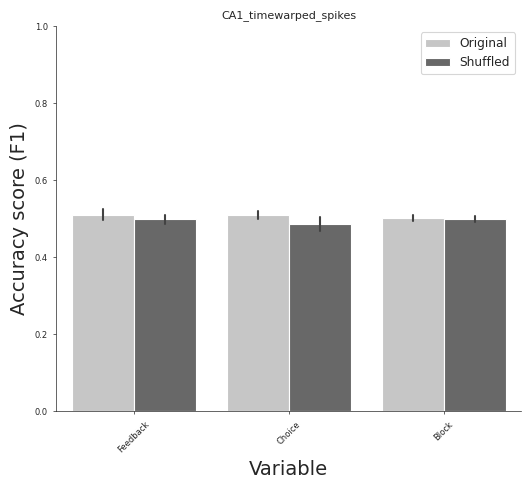

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


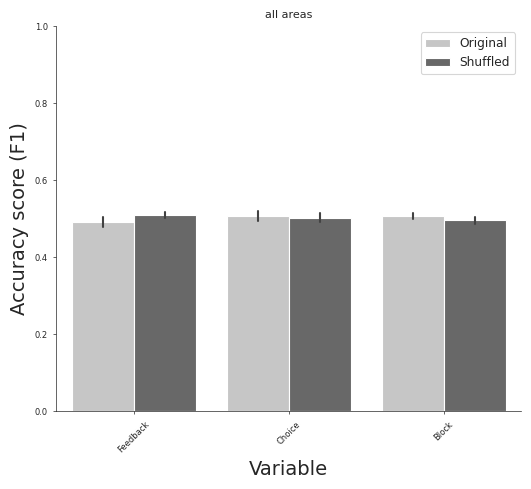

Processed session 76/89: c4432264-e1ae-446f-8a07-6280abade813


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2128 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 2128 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


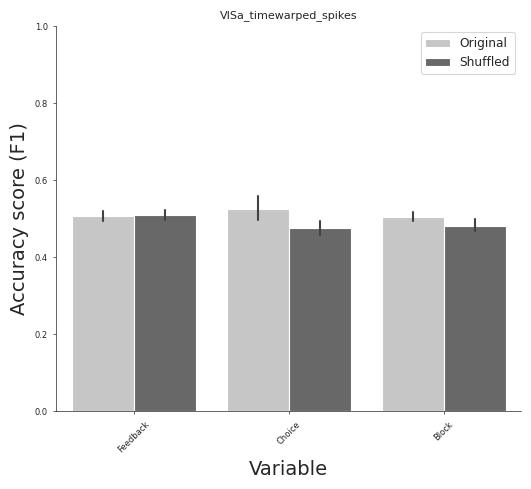

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


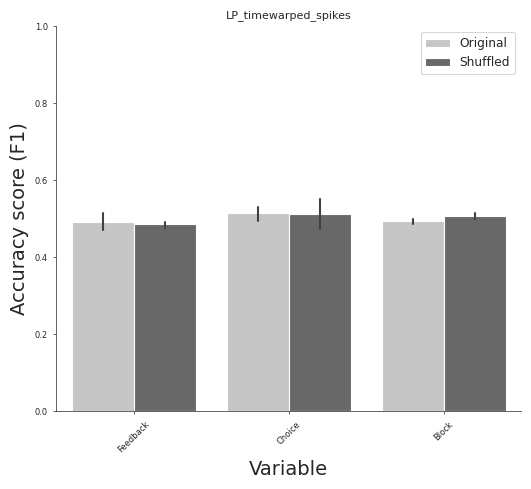

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


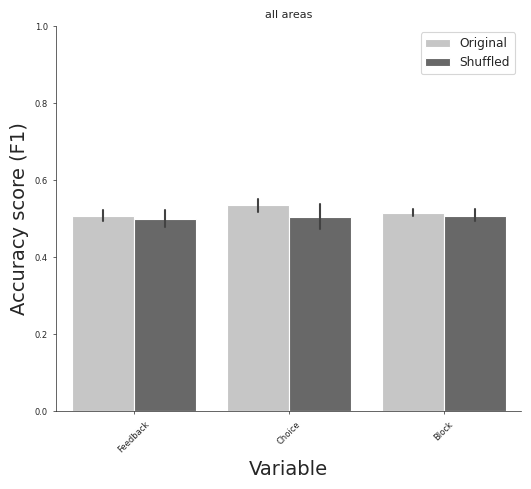

Processed session 77/89: dc962048-89bb-4e6a-96a9-b062a2be1426
No behavior for session 78/89: 38d95489-2e82-412a-8c1a-c5377b5f1555
Processed session 78/89: 38d95489-2e82-412a-8c1a-c5377b5f1555
Processed session 79/89: 0841d188-8ef2-4f20-9828-76a94d5343a4


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 3254 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


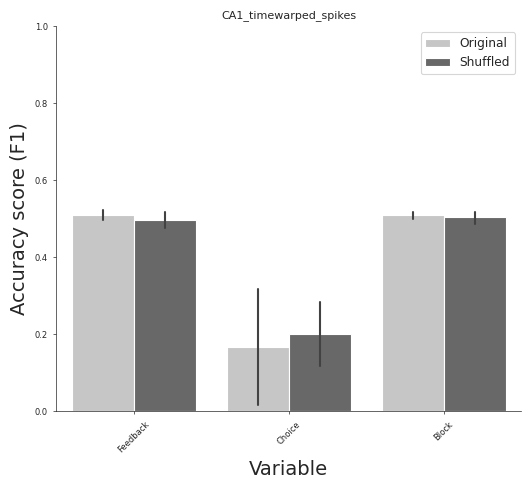

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


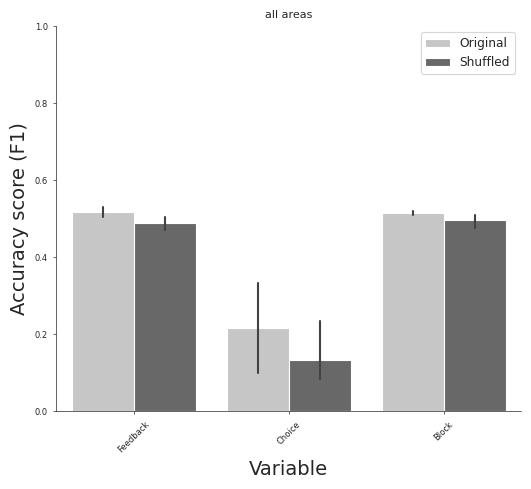

Processed session 80/89: 91bac580-76ed-41ab-ac07-89051f8d7f6e


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 2766 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


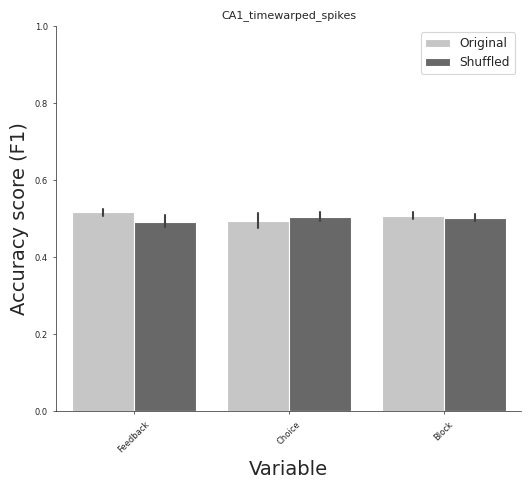

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


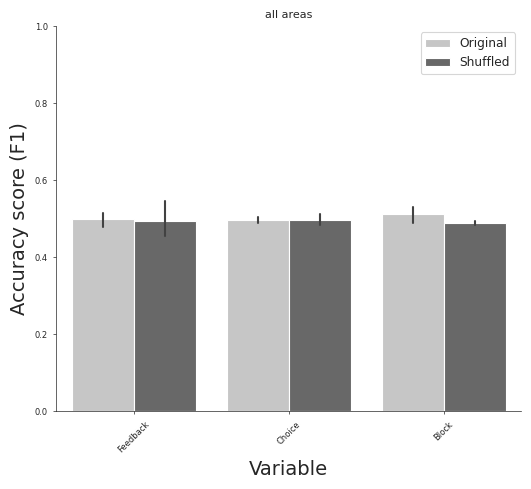

Processed session 81/89: 9b528ad0-4599-4a55-9148-96cc1d93fb24


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISam
Processed 4703 samples for VISam
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


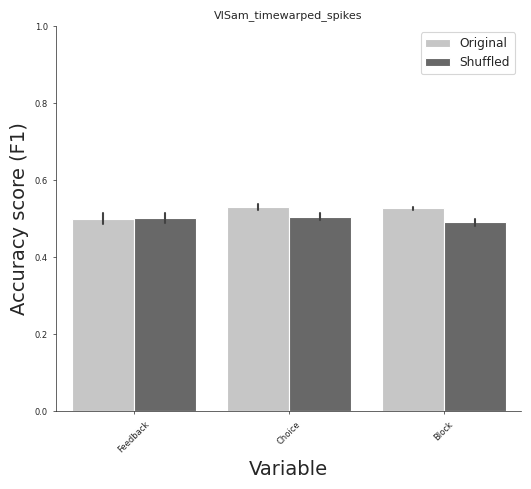

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


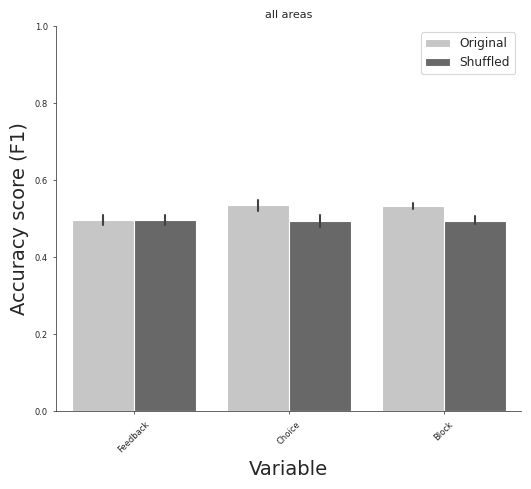

Processed session 82/89: 6c6b0d06-6039-4525-a74b-58cfaa1d3a60


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 4735 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: CA1
Processed 4735 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


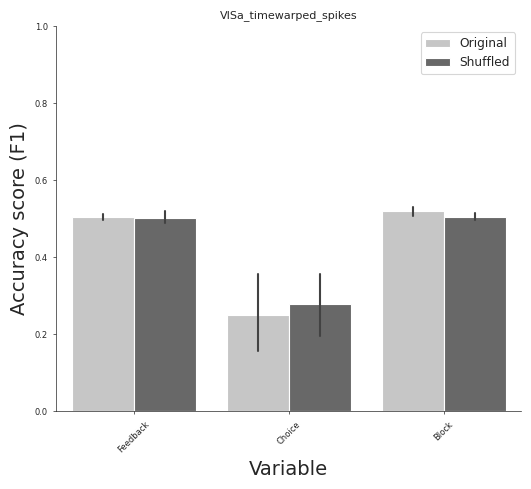

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


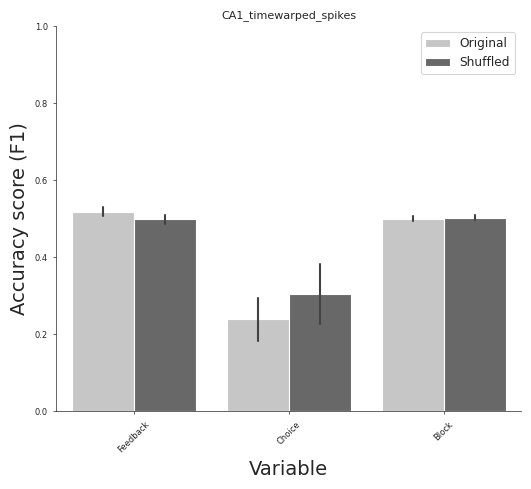

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


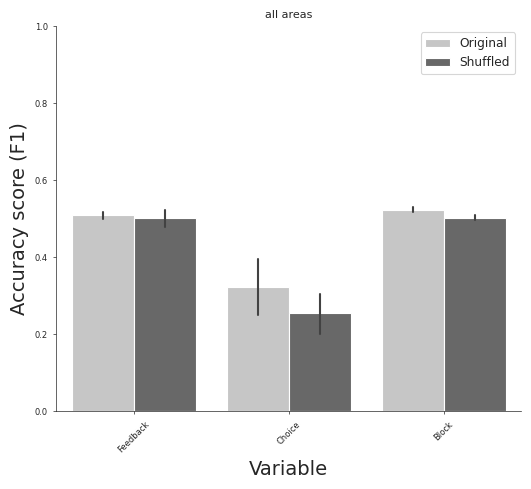

Processed session 83/89: 7f6b86f9-879a-4ea2-8531-294a221af5d0
No behavior for session 84/89: 1b715600-0cbc-442c-bd00-5b0ac2865de1
Processed session 84/89: 1b715600-0cbc-442c-bd00-5b0ac2865de1


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 1969 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 1969 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: PO
Processed 1969 samples for PO
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


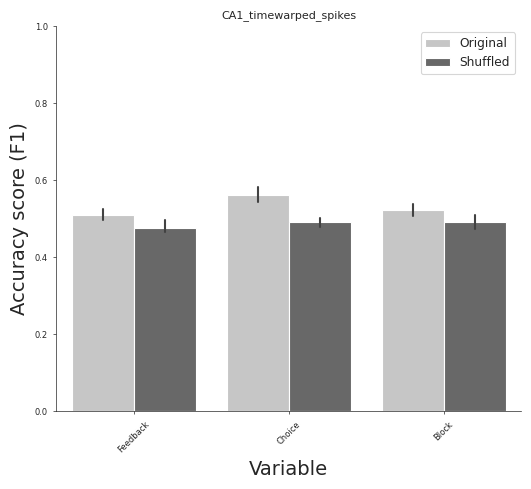

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


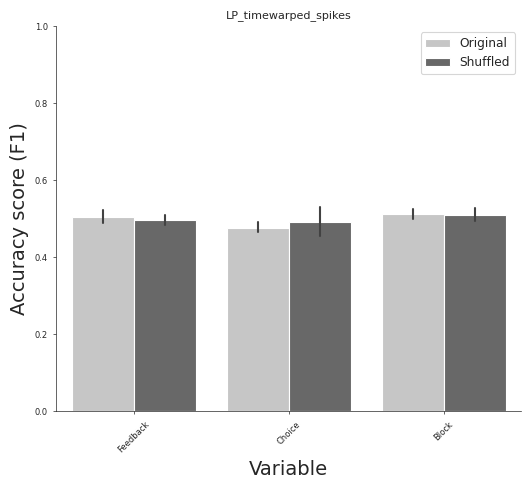

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


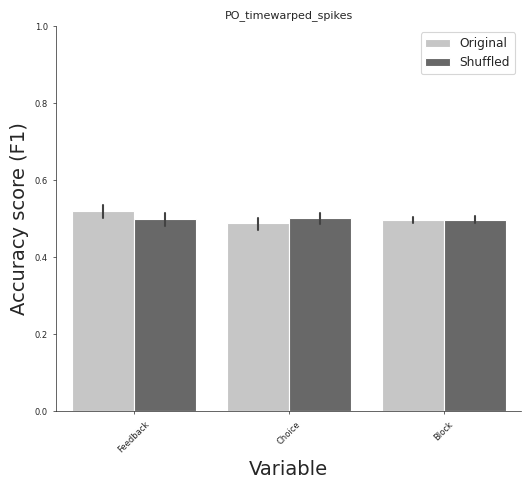

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


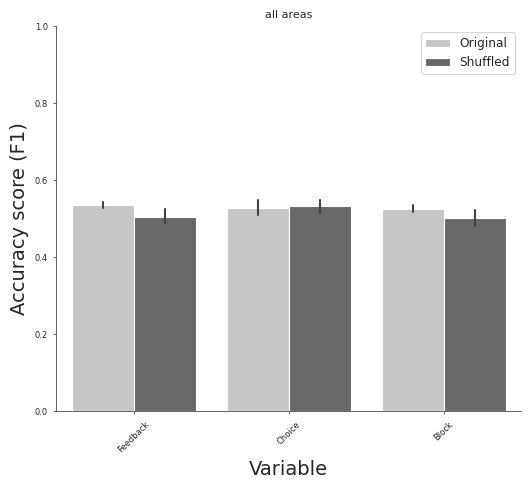

Processed session 85/89: d23a44ef-1402-4ed7-97f5-47e9a7a504d9
Processed session 86/89: 239dd3c9-35f3-4462-95ee-91b822a22e6b


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: CA1
Processed 1935 samples for CA1
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']
Processing area: LP
Processed 1935 samples for LP
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


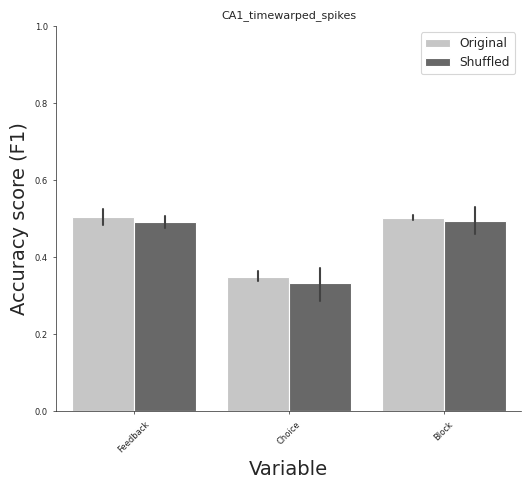

/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


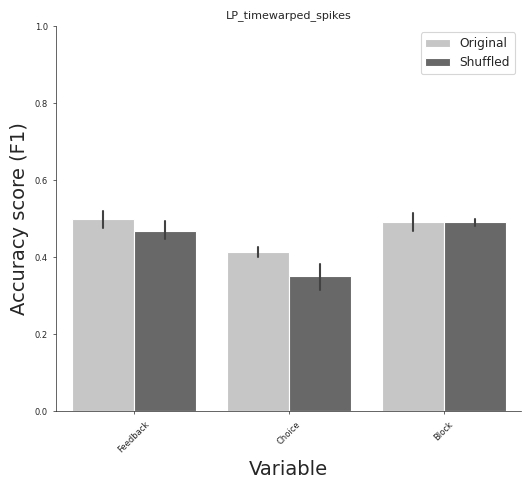

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


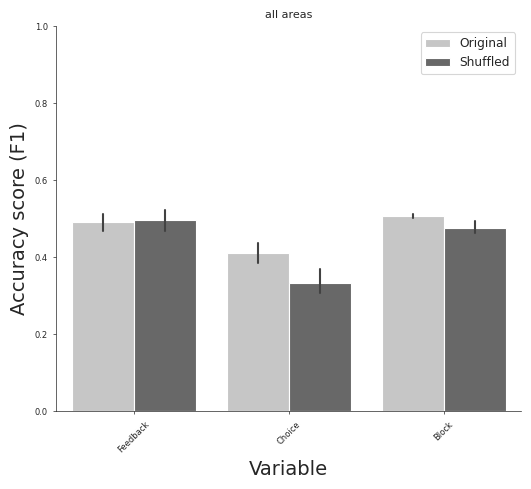

Processed session 87/89: 8a3a0197-b40a-449f-be55-c00b23253bbf


/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trial_type['correct_str'] = states_trial_type['correct']
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:375: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/2_pre-trial/functions.py:377: 

Processing area: VISa
Processed 2542 samples for VISa
Unique broader labels: ['Choice' 'ITI' 'Stimulus' 'Pre-quiescence' 'Quiescence']


/tmp/ipykernel_25797/2454799788.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2454799788.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


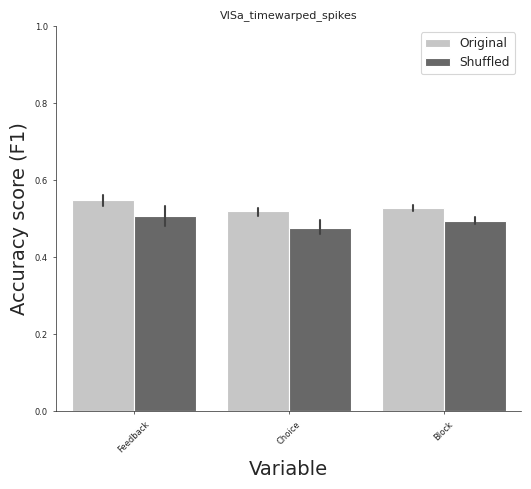

/tmp/ipykernel_25797/2718091513.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])
/tmp/ipykernel_25797/2718091513.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='type', y='value', hue='variable',


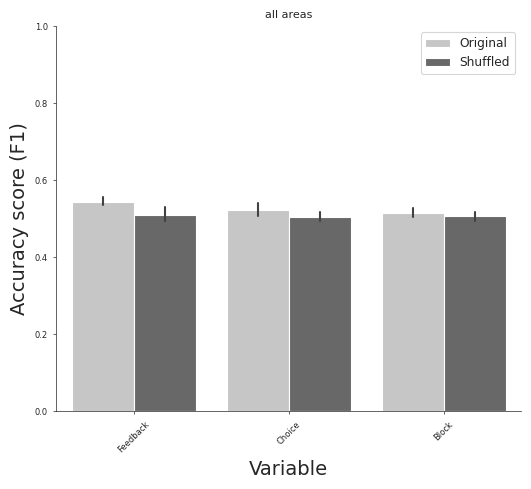

Processed session 88/89: 3e6a97d3-3991-49e2-b346-6948cb4580fb
Processed session 89/89: 03d9a098-07bf-4765-88b7-85f8d8f620cc


In [36]:
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions

# Storage for results - now includes session
cv_results = {
    'brain_region': [],
    'session': [],
    'model_type': [],
    'mean_r2': []}

for p, pid in enumerate(list(use_eid)):
    # try:
    ssl = SpikeSortingLoader(one=one, pid=pid)
    eid = ssl.eid
    session_files = glob.glob(os.path.join(save_states_path, f"*{eid}*"))
    if session_files:
        session_file_path = session_files[0]  # Take the first (and only) match
        states_trial = pd.read_parquet(session_file_path)
        
        # Initialize the final dataframe with states_trial
        states_trial_with_spikes = states_trial.copy()

        # Add session identifier
        states_trial_with_spikes['session_eid'] = eid
        states_trial_with_spikes['session_pid'] = pid
        
        # Assuming states_trial has 'Bin' column with timestamps and some bin width
        bin_width = states_trial['Bin'].diff().median()  # or specify manually
        
        areas_to_timewarp = []
        for a, area in enumerate(BRAIN_REGIONS):  
            regions = BrainRegions()
            aca_leaf_nodes = regions.descendants(regions.acronym2id(area))
            spikes, clusters, channels = ssl.load_spike_sorting(good_units=True, revision='2025-05-26')
            df_clus = pd.DataFrame(ssl.merge_clusters(spikes, clusters, channels))
            
            # This is where we select the units belonging to any of the leaf nodes brain regions
            selection_clusters = df_clus['atlas_id'].isin(aca_leaf_nodes['id'])
            iclusters = np.where(selection_clusters)[0]
            # We extend the selection to the spikes that belong to the selected clusters
            ispikes = np.isin(spikes['clusters'], iclusters)
            st = spikes['times'][ispikes]
            sc = spikes['clusters'][ispikes]
            
            # Get the time bins from states_trial
            time_bins = states_trial['Bin'].values
            # Create bin edges for histogram
            # We need n+1 edges for n bins, so we need to extrapolate the bin edges
            bin_width = np.median(np.diff(time_bins))  # Estimate bin width (~1/60 = 0.0167 seconds)
            # Create bin edges: start from half bin width before first bin, end half bin width after last bin
            bin_edges = np.concatenate([
                [time_bins[0] - bin_width/2],  # Start edge
                time_bins[:-1] + bin_width/2,  # Middle edges
                [time_bins[-1] + bin_width/2]  # End edge
            ])
            # Filter spikes to only include those within the states_trial time range
            time_mask = (st >= bin_edges[0]) & (st <= bin_edges[-1])
            st_filtered = st[time_mask]
            sc_filtered = sc[time_mask]
            
            # Create spike counts for each cluster in each time bin
            spike_counts = []
            if len(np.unique(sc_filtered)) >= 10:
                areas_to_timewarp.append(area)
                # print(area, len(np.unique(sc_filtered)))
                for cluster_id in np.unique(sc_filtered):
                    cluster_spikes = st_filtered[sc_filtered == cluster_id]
                    # Use histogram to bin spikes into the same time bins as states_trial
                    counts, _ = np.histogram(cluster_spikes, bins=bin_edges)
                    spike_counts.append(counts)

                # Convert to array and take average across all clusters
                if len(spike_counts) > 0:
                    spike_counts_array = np.array(spike_counts)
                    avg_spike_counts = np.mean(spike_counts_array, axis=0)
                else:
                    # Handle case where no clusters are found for this brain region
                    avg_spike_counts = np.zeros(len(states_trial))

                # Add this brain region's spike counts as a new column
                states_trial_with_spikes[f'{area}_spike_count'] = avg_spike_counts
                
        states_trial_with_spikes['trial_epoch'] = states_trial_with_spikes['label']
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Stimulus left', 'trial_epoch'] = 'Stimulus'
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Stimulus right', 'trial_epoch'] = 'Stimulus'
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Left choice', 'trial_epoch'] = 'Choice'
        states_trial_with_spikes.loc[states_trial_with_spikes['label'] == 'Right choice', 'trial_epoch'] = 'Choice'  

        # Timewarp per area
        if len(areas_to_timewarp) > 0:
            result_df = process_timewarped_spikes_all_areas(states_trial_with_spikes, areas_to_timewarp, plot=False)
            all_results = decode_per_area(result_df)
            all_results = decode_across_areas(result_df)
        
    else:
        print(f"No behavior for session {p+1}/{len(use_eid)}: {eid}")
#     # Add this session's data to the list
#     all_sessions_data.append(states_trial_with_spikes)
    print(f"Processed session {p+1}/{len(use_eid)}: {eid}")
    # except:
    #     print(f"Failed to process session {p+1}/{len(use_eid)}: {eid}")

# # Stack all sessions into a single dataframe
# final_stacked_data = pd.concat(all_sessions_data, ignore_index=True)
# print(f"Final stacked dataframe shape: {final_stacked_data.shape}")